# Collect AVH Data for Analysis
The following code brings together data generated and collected by Feng, Changye, and George into a single dataframe for future analysis. Right now the focus is on transcript level information for the sandwich analysis.

TODO

    1) How to handle NAs? Can implement smarter NA handling by only removing rows that have NAs in the columns we care about
    2) Log of WER
    3) Add in pause proportion
    4) Do not use SNR for WER

## Import libraries and functions

In [454]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# import statsmodels.api as sm
# from statsmodels.regression.mixed_linear_model import MixedLM
import numpy as np
from io import StringIO
from pathlib import Path

# directory_path = Path("another_new_directory")

# directory_path.mkdir(parents=True, exist_ok=True)
# print(f"Directory '{directory_path}' ensured to exist.")
out_folder = "/edata/obdw/sandwich_analysis_data/"

In [455]:
# Import shared utilities
import sys
import importlib
sys.path.insert(0, '/home/NETID/emd5')
import avh_utils
# Reload in case the module has been updated
importlib.reload(avh_utils)
from avh_utils import decode_variable_name, data_dictionary

In [456]:
def process_uid(series: pd.SparseDtype) -> pd.Series:
    """
    Extract unique pid from file names in a pandas Series. From Changye Li

    Args:
        series (pd.Series): Series containing file names of the transcripts

    Returns:
        pd.Series: Series with processed PIDs as integers
    """
    # Split the strings and get the first element (pid part)
    pids = series.str.split('-').str[0]
    
    # Clean up the pid strings
    pids = (pids.str.rstrip('@avh')
                .str.lstrip('u')
                .str.lstrip('0')
                .astype(int))
    
    return pids

## Read in Data

In [457]:
ptcpt_baseline_path = "/edata/changye/restore/avh-data/avh_record_baseline_kwargs.jsonl"# I wil use this file as the main
#this was old path
#ptcpt_baseline_path = "/edata/changye/avh-data/avh_record_baseline_kwargs.jsonl"# I wil use this file as the main

# rcd_whisperx_scores_path = "/edata/feng/avh/whisperx_baseline_with_time_wer_english_full.json"
# old path
rcd_whisperx_scores_path = "/edata/feng/avh/whisperx_merged_with_manual.json" #"/edata/feng/avh/whisperx_full_cleaned.json"
rcd_snr_path = "/edata/changye/restore/avh-new/data/snr.csv"
#rcd_snr_path = "/edata/changye/avh-new/data/snr.csv"
rcd_mos_path = "/edata/changye/restore/avh-data/pred_mos.csv"
rcd_coh_recording_level_path = "/edata/george/debias_merged_new.csv"




In [458]:
baseline_df = pd.read_json(ptcpt_baseline_path, lines=True)
baseline_df = baseline_df.set_index("pid", drop=True).rename_axis("file")
baseline_df = baseline_df.rename(columns={"uid":"pid"})
baseline_df.shape
list(baseline_df.columns)

['pid',
 'record',
 'transcription',
 'audio',
 'prediction',
 'wer',
 'cer',
 'record_date',
 'in_person',
 'days of data',
 'audio diary entries',
 'age',
 'gender',
 'phone',
 'data_plan',
 'ah_freq',
 'location',
 'availability',
 'future_contact',
 'comp_q1',
 'comp_q2',
 'comp_q3',
 'comp_q4',
 'comp_q5',
 'race',
 'hispanic',
 'marital-status',
 'sexuality',
 'education',
 'employment-status',
 'living-status',
 'basic-cell',
 'smartphone',
 'tablet',
 'computer',
 'wearable-tech',
 'email',
 'social-media',
 'verify-hearing-voices',
 'how-often',
 'how-long',
 'diagnoses',
 'dx-alzheimers-parkinsons',
 'dx-bipolar-disorder',
 'dx-depression',
 'dx-tbi',
 'dx-migraines',
 'dx-schizoaffective-disorder',
 'dx-schizophrenia',
 'dx-ptsd',
 'dx-substance-use',
 'dx-seizures',
 'dx-none-of-the-above',
 'dx-other',
 'used-treatment',
 'type-of-treatments',
 'tx-one-on-one',
 'tx-online',
 'tx-group',
 'tx-partial-hospitalization',
 'tx-alcohol-drug-rehab',
 'tx-telepsychiatry',
 'tx-re

In [459]:
baseline_df = pd.read_json(ptcpt_baseline_path, lines=True)
baseline_df = baseline_df.set_index("pid", drop=True).rename_axis("file")
baseline_df = baseline_df.rename(columns={"uid":"pid"})

rcd_whisperx_scores_df = pd.read_json(rcd_whisperx_scores_path, lines=True)
rcd_whisperx_scores_df = rcd_whisperx_scores_df.set_index("file", drop=True)#.rename_axis("file")
# rcd_whisperx_scores_df["pid"] = process_uid(rcd_whisperx_scores_df.pid)


rcd_snr_df = pd.read_csv(rcd_snr_path)
rcd_snr_df = rcd_snr_df.set_index("file")
rcd_snr_df["pid"] = process_uid(rcd_snr_df.index)

rcd_mos_df = pd.read_csv(rcd_mos_path)
rcd_mos_df = pd.DataFrame(rcd_mos_df.groupby(['file_name'])['pred_mos'].mean())
rcd_mos_df["pid"] = process_uid(rcd_mos_df.index)


rcd_level_coh_df = pd.read_csv(rcd_coh_recording_level_path)# Similar to above but for recordings.
rcd_level_coh_df["file"] = rcd_level_coh_df.file.apply(lambda x: x.strip(".txt"))
rcd_level_coh_df = rcd_level_coh_df.set_index("file")
rcd_level_coh_df["pid"] = process_uid(rcd_level_coh_df.index)


In [460]:
list(rcd_whisperx_scores_df.columns)

['segments',
 'prediction',
 'time_diffs',
 'pause_proportion',
 'pid',
 'record',
 'text',
 'audio',
 'wer',
 'cer']

In [461]:
list(rcd_snr_df.columns)

['snr', 'pid']

In [462]:
list(rcd_mos_df.columns)

['pred_mos', 'pid']

In [463]:
#list(rcd_level_coh_df.columns)

In [464]:
list(rcd_snr_df.columns)

['snr', 'pid']

In [465]:
print("Baseline scores shape", baseline_df.shape)
print("Whisper scores shape", rcd_whisperx_scores_df.shape)
print("SNR shape", rcd_snr_df.shape)
print("MOS shape", rcd_mos_df.shape)
print("COH shape", rcd_level_coh_df.shape)

Baseline scores shape (2904, 128)
Whisper scores shape (2994, 10)
SNR shape (3003, 2)
MOS shape (2981, 2)
COH shape (3003, 133)


## Clean Data

### Check transcript file names

In [466]:
baseline_files = set(baseline_df.index)
whisper_files = set(rcd_whisperx_scores_df.index)
snr_files = set(rcd_snr_df.index)
mos_files = set(rcd_mos_df.index)
coh_files = set(rcd_level_coh_df.index)

file_names_union = whisper_files.union(snr_files).union(mos_files).union(coh_files).union(baseline_files)
file_names_intersection = whisper_files.intersection(snr_files).intersection(mos_files).intersection(coh_files).intersection(baseline_files)
print("There are a total of {:,} file names and only {:,} at the intersection".format(len(file_names_union), len(file_names_intersection)))

There are a total of 3,007 file names and only 2,886 at the intersection


### Remove duplicated columns
Not all will be removed but this should clean it up some

In [467]:
def remove_duplicated_columns(main_df, secondary_df, extra_cols_to_drop, protected_cols = set(["pid"])):
    """
    Description: removes duiplicated columns from secondary_df which main_df already contains
    Input:
        main_df (pandas df): dataframe
        secondary_df (pandas df): dataframe
        extra_cols_to_drop (list or set): Additional column names to drop from extra cols. Useful if you know cols
            are duplicates but with different names
        protected_cols (list or set): Columns not to drop.  THIS IS NO LONGER USED AND DOES NOT WORK ANYWAY
    Output:
        updated_df: (pandas df): same as secondary_df, but with duplicated columns removed
    TODO
        1)
    """

    intersection_columns = set(main_df).intersection(secondary_df).union(extra_cols_to_drop)
    print(intersection_columns)
    print("cols dropped", len(intersection_columns))
    updated_df = secondary_df.drop(intersection_columns, axis=1)
    print("new shape", updated_df.shape)
    return(updated_df)

In [468]:
coh_cols_to_drop = ['contact',
 'temper-outbursts',
 'feeling-blocked',
 'worrying-too-much',
 'easily-hurt',
 'feeling-watched',
 'feeling-tense',
 'heavy-feelings-in-arms-legs',
 'feeling-nervous',
 'feeling-lonely',
 'frequency',
 'bad-voices',
 'volume-of-voices',
 'voices-length',
 'interference-in-activities',
 'distressing-voices',
 'worthless-useless-voices',
 'clarity-of-voices',
 'follow-voices-orders',
 'time-of-day-of-voices',
 'social-situations',
 'where-are-the-voices',
 'typical-week',
 'if-no-explanation',
 'work-school-disruption',
 'social-leisure-disruption',
 'home-family-disruption',
 'school-work-missed',
 'less-productive-days',
#  'not-worked-for-other-reasons',# not removed since this is one George suggested to keep
 'little-interest-or-pleasure',
 'feeling-depressed',
 'trouble-sleeping',
 'feeling-tired',
 'appetite',
 'feeling-bad-about-self',
 'trouble-concentrating',
 'slow-fast-speaking',
 #'suicidal-thoughts',
 'impact-on-your-life', 'text']

In [469]:
print("Removing columns from coh df")
rcd_level_coh_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_level_coh_df, extra_cols_to_drop=coh_cols_to_drop)
print("\n\nRemoving columns from whisperx df")
rcd_whisperx_scores_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_whisperx_scores_df, extra_cols_to_drop=["text"])
print("\n\nRemoving columns from mos df")
rcd_mos_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_mos_df, extra_cols_to_drop=[])
print("\n\nRemoving columns from snr df")
rcd_snr_df = remove_duplicated_columns(main_df=baseline_df, secondary_df=rcd_snr_df, extra_cols_to_drop=[])

Removing columns from coh df
{'where-are-the-voices', 'tablet', 'feeling-depressed', 'email', 'marital-status', 'social-leisure-disruption', 'age', 'school-work-missed', 'smartphone', 'worthless-useless-voices', 'hispanic', 'social-situations', 'basic-cell', 'volume-of-voices', 'feeling-bad-about-self', 'less-productive-days', 'text', 'if-no-explanation', 'phone', 'used-treatment', 'contact', 'little-interest-or-pleasure', 'employment-status', 'follow-voices-orders', 'type-of-treatments', 'diagnoses', 'location', 'comp_q2', 'computer', 'time-of-day-of-voices', 'comp_q1', 'home-family-disruption', 'appetite', 'comp_q5', 'comp_q4', 'wearable-tech', 'feeling-tense', 'trouble-sleeping', 'availability', 'voices-length', 'frequency', 'distressing-voices', 'trouble-concentrating', 'easily-hurt', 'verify-hearing-voices', 'interference-in-activities', 'data_plan', 'how-long', 'feeling-watched', 'temper-outbursts', 'feeling-nervous', 'living-status', 'feeling-blocked', 'education', 'substances-u

## Merge Data

In [470]:
main_analysis_df = pd.concat([baseline_df, rcd_whisperx_scores_df, rcd_snr_df, rcd_mos_df, rcd_level_coh_df], axis=1, join="inner")
assert main_analysis_df.shape[0] == len(file_names_intersection)
print(main_analysis_df.shape)
#print(main_analysis_df.columns)
#print(main_analysis_df.columns.tolist())

(2886, 190)


In [471]:
# Check that each participant has consistent location data across all transcripts
# Assumes you have a DataFrame with 'pid' as participant ID and location columns (e.g., 'PrimaryRUCA', 'RPL_THEMES', etc.)

#ToD0: location isn't merged in this high, move cell after location merge
location_columns = [
    'PrimaryRUCA', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4',
    'doctor_count', 'pharmacy_count', 'hospital_count', 'park_count', 'bus_station_count', 'supermarket_count', 'cluster'
]

# Replace 'main_analysis_df' with the actual DataFrame variable name containing these columns
df_location = main_analysis_df[['pid'] + [col for col in location_columns if col in main_analysis_df.columns]].copy()

# Group by participant and check for unique location rows
inconsistent_pids = []
for pid, group in df_location.groupby('pid'):
    # Drop duplicate location rows for this participant
    unique_locs = group[[col for col in location_columns if col in group.columns]].drop_duplicates()
    if len(unique_locs) > 1:
        inconsistent_pids.append(pid)
    if pid == 8: 
        print(unique_locs)


if inconsistent_pids:
    print(f"WARNING: Found {len(inconsistent_pids)} participants with inconsistent location data across transcripts.")
    print("Participant IDs with inconsistent location data:", inconsistent_pids)
else:
    print("All participants have consistent location data across transcripts.")

#ToDo: moved this code around, doesn't work
# Have to redo the above code to check for consistency of location data across transcripts. I moved it around and it doesn't work anymore, not sure why.


Empty DataFrame
Columns: []
Index: [u00000008@avh-20180311-1, u00000008@avh-20180329-1]
Participant IDs with inconsistent location data: [3, 8, 50, 55, 57, 79, 88, 90, 105, 115, 118, 123, 134, 162, 170, 235, 240, 253, 275, 281, 305, 313, 333, 341, 366, 373, 374, 382, 383, 392, 396, 409, 413, 441, 443, 448, 449, 450, 457, 472, 478, 485, 500, 509, 518, 520, 564, 581, 600, 606, 649, 652, 669, 677, 681, 688, 703, 705, 706, 739, 747, 768, 796, 802, 803, 814, 815, 827, 831, 844, 847, 848, 866, 879, 896, 919, 928, 933, 949, 960, 962, 963, 967, 993, 1008, 1010, 1017, 1020, 1035, 1037, 1042, 1063, 1081, 1088, 1155, 1166, 1172, 1179, 1204, 1206, 1211, 1228, 1247, 1248, 1251, 1252, 1261, 1283, 1293, 1295, 1296, 1319, 1322, 1325, 1350, 1351, 1352, 1358, 1363, 1377, 1396, 1405, 1425, 1435, 1441, 1442, 1450, 1460, 1461, 1489, 1493, 1499, 1501, 1515, 1517, 1524, 1529, 1537, 1553, 1558, 1574, 1580, 1595, 1597, 1607, 1621, 1639, 1643, 1644, 1651, 1665, 1679, 1682, 1683, 1686, 1690, 1691, 1706, 1714, 17

In [472]:
# Explore a few participants with inconsistent location data across transcripts
# Pick a few participant IDs from inconsistent_pids
example_pids = inconsistent_pids[:3]  # You can change the number or pick specific IDs

# for pid in example_pids:
#     print(f"\nParticipant {pid} - Location data across transcripts:")
#     display(df_location[df_location['pid'] == pid])
#     # Show unique location rows for this participant
#     unique_locs = df_location[df_location['pid'] == pid][[col for col in location_columns if col in df_location.columns]].drop_duplicates()
#     #print(f"Unique location rows for participant {pid}:")
#     #display(unique_locs)


## Remove NA
I am ignoring certain columns I do not expect to use. Like many of the coherence columns. Otherwise we would be dropping many columns with NAs that we would never use.

In [473]:
columns2ignore_na = ["not-worked-for-other-reasons"]
for column_name in main_analysis_df.columns:
    if "Coherence" in column_name and column_name != "sentCoherenceSentBertCumulativeCentroid":# the one we care about is sentCoherenceSentBertCumulativeCentroid
        columns2ignore_na.append(column_name)
# Code below just to look at columns with na
#  for x, y in zip(main_analysis_df.columns, list(main_analysis_df.isna().sum())):
#     if x in columns2ignore_na:
#         continue
#     print(x, y)
main_analysis_df.drop(columns2ignore_na, axis=1, inplace=True)
main_analysis_df.dropna(axis=0, inplace=True)
# main_analysis_df


In [474]:
main_analysis_df.to_csv(out_folder + "main_merged_sandwich_analysis_data.csv")

In [475]:
temp = pd.read_csv(out_folder + "main_merged_sandwich_analysis_data.csv", index_col=0)

In [476]:
main_analysis_df.shape

(2859, 154)

## Identify Features for Analysis
The next step is to identify subsets of features to use for sandwich analysis. Listing the features and response variable out should not be hard for each analysis. Removing nan values will depend more on the response variable I believe, since nan categorical variables can be coded up in one-hot encoding. However it might be wise to remove rows with any nan values.

### Options for final cleaning

1) Remove nan values from each dataframe on a per analysis criteria
2) Remove nan values from the overall dataframe so each analysis is working with the same dataframe.
3) A hybrid approach of the above where rows are removed based off of nan values in the features from the overall dataframe and then nan values are removed in the response variable on a per analysis criteria.

## Feature Engineering
As of now, this is only one-hot encoding code I have from the previous analysis

In [477]:
#list(main_analysis_df.columns.tolist())

In [478]:
# Loop through all columns in X_basic_plus_clin_sdh_location_encoded except 'WER' and run a simple linear regression (WER ~ variable)

# Univariate regression results will be used to identify which variables are significantly associated with WER, 

# and to understand the direction and magnitude of these associations. 

# This will help us identify potential predictors of WER and inform our multivariate regression model later on.

import pandas as pd

import statsmodels.api as sm

from statsmodels.iolib.summary2 import summary_col



# Load the data if not already loaded

data_path = '/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_encoded.csv'

df = pd.read_csv(data_path)



# Identify the WER column: try multiple candidates

wer_candidates = ['WER', 'wer', 'log_wer', 'Y_WER']

wer_col = next((col for col in wer_candidates if col in df.columns), None)

if not wer_col:

    raise ValueError(f'WER column not found in the data. Tried: {wer_candidates}. Available: {list(df.columns)}')



# Loop through all columns except WER

# ToDo: Indiviual Variables

# Bar Plots = green coding if significant, red if not, and show the beta values on the plot. This is important for understanding the direction and magnitude of the relationship, and for visually communicating the results to others.

# ToDo: add the sandwich correction to the regression to account for non-independence of observations within participants. This is important because we have multiple transcripts per participant, and we want to make sure our standard errors are correct.

regression_results = {}

for col in df.columns:

    if col == wer_col or col == 'pid':

        continue

    # Drop NA for the current variable and WER

    temp = df[[wer_col, col, 'pid']].dropna()

    if temp.empty:

        continue  # Skip if there's no data after dropping NA

    

    vals = temp[col]  # might be Series OR DataFrame

    if isinstance(vals, pd.DataFrame):

        vals = vals.iloc[:, 0]



    nuniq = vals.nunique(dropna=True)



    # If vals is a DataFrame, nuniq is a Series (one per column)

    if isinstance(nuniq, pd.Series):

        if (nuniq < 2).any():   # or .all(), depending on intent

            continue

    else:

        if nuniq < 2:

            continue

    # Need at least 2 clusters for clustered SEs.

    pid = temp.loc[:, 'pid']

In [479]:
import importlib
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from patsy.builtins import Q
import avh_utils
importlib.reload(avh_utils)

# ── Config ────────────────────────────────────────────────────────────────────
data_path   = '/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_encoded.csv'
output_path = '/home/NETID/emd5/Univariate_Regression_from_X_basic_plus_clin_sdh_location_encoded.csv'

df = pd.read_csv(data_path)

# Identify WER column
wer_candidates = ['Y_WER', 'WER', 'wer', 'log_wer']
wer_col = next((c for c in wer_candidates if c in df.columns), None)
if not wer_col:
    raise ValueError(f'WER column not found. Available: {list(df.columns)}')

print(f"Running univariate regressions: WER column = '{wer_col}', "
      f"{df.shape[0]} rows, {len(df.columns) - 3} predictor candidates")

# ── Univariate regression loop (clustered SEs by pid) ─────────────────────────
rows    = []
skipped = []

for col in df.columns:
    if col in (wer_col, 'pid', 'Y_COH'):
        continue

    temp = df[[wer_col, col, 'pid']].dropna()

    if temp.empty or temp[col].nunique() < 2 or temp['pid'].nunique() < 2:
        skipped.append(col)
        continue

    try:
        safe_col = col.replace('"', '')
        formula  = f'{wer_col} ~ Q("{safe_col}")'
        model    = smf.ols(formula=formula, data=temp).fit(
            cov_type='cluster',
            cov_kwds={'groups': temp['pid'], 'use_correction': True}
        )
        # params.iloc[0] = intercept, params.iloc[1] = predictor coefficient
        rows.append({
            'Variable':      col,
            'Coefficient':   model.params.iloc[1],
            'p-value':       model.pvalues.iloc[1],
            'N':             int(model.nobs),
            'R-squared':     model.rsquared,
            'Adj R-squared': model.rsquared_adj,
            'F-statistic':   model.fvalue,
            'F p-value':     model.f_pvalue,
        })
    except Exception as e:
        skipped.append(f'{col} ({e})')

# ── Build results DataFrame ────────────────────────────────────────────────────
results_df = pd.DataFrame(rows)
results_df['Variable_Decoded'] = results_df['Variable'].apply(avh_utils.decode_variable_name)
results_df = results_df.sort_values('p-value').reset_index(drop=True)

# ── Save ───────────────────────────────────────────────────────────────────────
results_df.to_csv(output_path, index=False)
print(f"Saved {len(results_df)} rows → {output_path}")
if skipped:
    print(f"Skipped {len(skipped)}: {skipped[:5]}{'...' if len(skipped) > 5 else ''}")

# ── Summary ────────────────────────────────────────────────────────────────────
sig = results_df[results_df['p-value'] < 0.05]
print(f"\nSignificant (p < 0.05): {len(sig)} of {len(results_df)} variables")
print(sig[['Variable_Decoded', 'Coefficient', 'p-value', 'N']].to_string(index=False))


Running univariate regressions: WER column = 'Y_WER', 2859 rows, 75 predictor candidates
Saved 75 rows → /home/NETID/emd5/Univariate_Regression_from_X_basic_plus_clin_sdh_location_encoded.csv

Significant (p < 0.05): 26 of 75 variables
                               Variable_Decoded  Coefficient      p-value    N
                                  Gender: Other     0.906554 1.167376e-74 2859
                   Gender: Transgender (F to M)    -0.695918 7.622693e-45 2859
  Psychoactive Substance Use (Ketamine or Acid)    -0.816104 4.164879e-44 2859
                             Sexuality: Unknown     0.595110 3.374994e-33 2859
         Primaryruca: Small Town High Commuting    -0.564701 4.879843e-29 2859
                    Signal-to-Noise Ratio (SNR)    -0.042272 1.331501e-27 2859
                   Primaryruca: Small Town Core    -0.450476 1.022675e-19 2859
        Primaryruca: Metropolitan Low Commuting    -0.619660 1.407197e-11 2859
             Predicted Mean Opinion Score (MOS)    -0

In [480]:
def one_hot_encode(df, cols2encode, missing_label="__MISSING__", forced_drop=None, prefer_drop=("other", "unknown"), fallback="most_frequent", verbose=True):
    """One-hot encode columns while explicitly selecting a reference category to drop per column."""
    df_enc = df[cols2encode].fillna(missing_label).astype(str)
    forced_drop = forced_drop or {}

    def _resolve_requested_category(requested, categories):
        requested_norm = str(requested).strip().lower()
        for cat in categories:
            if cat.strip().lower() == requested_norm:
                return cat

        try:
            requested_num = float(requested)
        except (TypeError, ValueError):
            requested_num = None

        if requested_num is not None:
            for cat in categories:
                try:
                    if float(cat) == requested_num:
                        return cat
                except (TypeError, ValueError):
                    continue
            return None

        for cat in categories:
            if requested_norm in cat.strip().lower():
                return cat
        return None

    drop_values = []
    dropped_map = {}

    for col in cols2encode:
        value_counts = df_enc[col].value_counts()
        categories = list(value_counts.index.astype(str))
        chosen = None

        if col in forced_drop:
            chosen = _resolve_requested_category(forced_drop[col], categories)
            if chosen is None:
                print(f"[one_hot_encode] Requested drop '{forced_drop[col]}' for '{col}' was not found. Falling back to automatic rule.")

        if chosen is None:
            for token in prefer_drop:
                chosen = _resolve_requested_category(token, categories)
                if chosen is not None:
                    break

        if chosen is None:
            if fallback == "least_frequent":
                chosen = str(value_counts.idxmin())
            else:
                chosen = str(value_counts.idxmax())

        drop_values.append(chosen)
        dropped_map[col] = chosen

    if verbose:
        print(f"[one_hot_encode] Dropped reference categories: {dropped_map}")

    try:
        enc = OneHotEncoder(drop=drop_values, sparse=False, handle_unknown="ignore", dtype=int)
    except TypeError:
        enc = OneHotEncoder(drop=drop_values, sparse_output=False, handle_unknown="ignore", dtype=int)

    enc.fit(df_enc)
    one_hot_encoded_df = pd.DataFrame(
        enc.transform(df_enc),
        columns=enc.get_feature_names_out(),
        index=df.index
    )
    return one_hot_encoded_df


In [481]:
# Keep a stable reference to the upgraded encoder even if a legacy redefinition appears later.
one_hot_encode_v2 = one_hot_encode

In [482]:
# Bin education into levels
binmappers = {
                "education":{
                    2.0: 1.0,# 1.0 means up to codes for education - data dictionary for things like HS diploma, College degree, etc.
                    3.0: 1.0,
                    4.0: 1.0,
                    5.0: 2.0,
                    6.0: 2.0,
                    7.0: 3.0,
                    8.0: 3.0,
                    np.nan:np.nan,
                }
           }
def bin_age(age):
    """
    Description: Bins all age value from an pandas series. To be used in an apply function
    Inputs:
        ages (float): Float age
    Outputs:
        age_bin (int): Int category for age bin
    TODO:
        1)
    """
    if np.isnan(age):
        age_bin = 0.0
    elif age == 999.0:
        age_bin = 0.0
    # elif age < 18.0:
    #     age_bin = 0.0
    elif age < 30.0:
        age_bin = 1.0
    elif age < 45.0:
        age_bin = 2.0
    elif age < 65.0:
        age_bin = 3.0
    else:
        age_bin = 4.0
    return(age_bin)

def replaced_age_with_binning(df):
    """
    Description: Wrapper for bin_age where the original age columns is dropped
    Inputs:
        df (pandas df): Pandas dataframe
    Outputs:
        df (pandas df): Same as input, but with age removed, and binned_age added
    TODO:
        1)
    """
    temp_df = df.copy(deep=True)
    temp_df["binned_age"] = temp_df.age.apply(lambda x: bin_age(x))
    temp_df.drop("age", axis=1, inplace=True)
    return(temp_df)


def bin_substance_use(data_df):
    """
    Decription: Bins a participants substance use. Only done for heroin and opioids
    Inputs:
         data_df (pandas DF): Dataframe containing substance use columns below
            "opioids","marijuana","alcohol","steroids","cocaine","heroin","nicotine","meth","ketamine","acid","bath-salts"
    Outputs:
    TODO
        1)
    """

    data_copy_df = data_df.copy(deep=True)
    # All Types of Drug Use: Did not include "nicotine"
    all_types_drug_use = ["opioids","marijuana","alcohol","steroids","cocaine","heroin","meth","ketamine","acid","bath-salts"]
    substances_of_interest = ["opioids","heroin"]
    substance_marijuana = ["marijuana"]
    substance_alcohol = ["alcohol"]
    substance_stimulant = ["cocaine","meth","ketamine","acid","bath-salts"]
    substance_nicotine = ["nicotine"]
    substance_psychoactive = ["ketamine","acid"]
    # Backward-compatible alias for earlier typo/variable name usage
    subtance_psychoactive = substance_psychoactive
    # type_2 = ["cocaine","heroin","nicotine","meth","ketamine","acid","bath-salts"]

    # Binarize the relevant substance columns (1 -> 1.0, else 0.0)
    data_copy_df.loc[:, all_types_drug_use] = pd.DataFrame(data_copy_df.loc[:, all_types_drug_use] == 1, dtype=np.float64)
    if "nicotine" in data_copy_df.columns:
        data_copy_df.loc[:, "nicotine"] = pd.Series(data_copy_df.loc[:, "nicotine"] == 1, dtype=np.float64)

    def build_group_flag(df, cols):
        existing_cols = [c for c in cols if c in df.columns]
        if not existing_cols:
            return pd.Series(np.zeros(len(df), dtype=np.float64), index=df.index)
        return pd.Series(df.loc[:, existing_cols].sum(axis=1) > 0, dtype=np.float64)

    opiods_opiates_1_use = build_group_flag(data_copy_df, substances_of_interest)
    all_types_drug_use_flag = build_group_flag(data_copy_df, all_types_drug_use)
    marijuana_use_flag = build_group_flag(data_copy_df, substance_marijuana)
    alcohol_use_flag = build_group_flag(data_copy_df, substance_alcohol)
    stimulant_use_flag = build_group_flag(data_copy_df, substance_stimulant)
    nicotine_use_flag = build_group_flag(data_copy_df, substance_nicotine)
    psychoactive_use_flag = build_group_flag(data_copy_df, subtance_psychoactive)

    data_copy_df.drop(labels=substances_of_interest, axis=1, inplace=True)
    data_copy_df["opioids-opiates"] = opiods_opiates_1_use
    data_copy_df["all_types_drug_use"] = all_types_drug_use_flag
    data_copy_df["substance_marijuana"] = marijuana_use_flag
    data_copy_df["substance_alcohol"] = alcohol_use_flag
    data_copy_df["substance_stimulant"] = stimulant_use_flag
    data_copy_df["substance_nicotine"] = nicotine_use_flag
    data_copy_df["substance_psychoactive"] = psychoactive_use_flag

    return(data_copy_df)


def one_hot_encode(df, cols2encode, missing_label="__MISSING__"):
    """
    One-hot encode `cols2encode`, dropping the first category
    per column. Converts category values to strings to ensure uniform types.
    """
    # copy, fill missing, and coerce to string (uniform dtype)
    df_enc = df[cols2encode].fillna(missing_label).astype(str)

    # sklearn compatibility for sparse vs sparse_output parameter
    try:
        enc = OneHotEncoder(drop='first', sparse=False, handle_unknown="ignore", dtype=int)
    except TypeError:
        enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore", dtype=int)

    enc.fit(df_enc)
    one_hot_encoded_df = pd.DataFrame(enc.transform(df_enc),
                                      columns=enc.get_feature_names_out(),
                                      index=df.index)
    return one_hot_encoded_df


### Create minimum analysis data: Basic
with race, age, and gender.

In [483]:
import sys, subprocess
try:
    import pyarrow
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow", "-q"])

# Load AMOS (Automatic MOS) scores for each recording session.
# File: /edata/changye/words_fail/data/merged_amos.parquet
# Column: ablated_amos -> renamed to AMOS
# Join key: 'file' column matches the recording-level index of the analysis DataFrames
amos_path = "/edata/changye/words_fail/data/merged_amos.parquet"
amos_df = (
    pd.read_parquet(amos_path)[["file", "ablated_amos"]]
    .rename(columns={"ablated_amos": "AMOS"})
    .set_index("file")
)
print(f"Loaded AMOS data: {len(amos_df)} recordings, {amos_df['AMOS'].isna().sum()} missing values")
print(amos_df["AMOS"].describe())


Loaded AMOS data: 3098 recordings, 0 missing values
count    3098.000000
mean        3.293043
std         0.963188
min         0.000000
25%         2.612126
50%         3.493932
75%         4.084477
max         4.753661
Name: AMOS, dtype: float64


In [484]:
cols2encode=["race", "gender", "binned_age"]

# X_temp = X_temp.replace(binmappers)# Mapping education to higher level categories

# X_temp.rename(columns={"education":"education_binned"},inplace=True)

minimum_analysis_df = replaced_age_with_binning(main_analysis_df)

minimum_analysis_df = minimum_analysis_df.loc[:, cols2encode + ["pid"]]

# When dropping Unknown values Keep race=999 (Unknown), gender=5 (Other), and binned_age=0 (Unknown) as the reference categories.
# problem with droppping unknown values is small n as reference group, 
# # So instead trying dropping the largest category as the reference group,  Largest categories below:   
#      "race": "1.0",             # White
#     "gender": "2.0",           # Male (or 1.0 Female)
#     "binned_age": "2.0",       # Age 30-45
#     "sexuality": "1.0",        # Heterosexual
#     "employment-status": "3.0", # Full-time work
#     "education_binned": "1.0"  # Grade school to HS (already good)

X_one_hot = one_hot_encode_v2(
    df=minimum_analysis_df,
    cols2encode=cols2encode,
    forced_drop={"race": 1, "gender": 2, "binned_age": 2},
)

X = minimum_analysis_df.drop(cols2encode, axis=1)

# Build response columns directly from main_analysis_df so this cell does not depend on prior Y_* variables.
# Force log-scale WER outcome for regression stability/comparability.
if "log_wer" not in main_analysis_df.columns:
    raw_wer_col = next((c for c in ["wer", "WER"] if c in main_analysis_df.columns), None)
    if raw_wer_col is None:
        raise KeyError("Missing required response column: one of ['log_wer', 'wer', 'WER']")
    main_analysis_df["log_wer"] = np.log1p(main_analysis_df[raw_wer_col].clip(lower=0))

wer_col = "log_wer"
coh_col = next((c for c in ["sentCoherenceSentBertCumulativeCentroid"] if c in main_analysis_df.columns), None)

if coh_col is None:
    raise KeyError("Missing required response column: 'sentCoherenceSentBertCumulativeCentroid'")

Y = main_analysis_df[[wer_col, coh_col]].copy()
Y = Y.rename(columns={wer_col: "Y_WER", coh_col: "Y_COH"})

X_min_analysis = pd.concat([X, X_one_hot, Y], axis=1, join="inner", ignore_index=False)

# Join AMOS score on recording-level index (index = recording file name)
X_min_analysis = X_min_analysis.join(amos_df[["AMOS"]], how="left")
print(f"AMOS joined: {X_min_analysis['AMOS'].notna().sum()} / {len(X_min_analysis)} rows matched")

X_min_analysis.to_csv(out_folder + "basic_analysis.csv")

#X_min_analysis


[one_hot_encode] Dropped reference categories: {'race': '1.0', 'gender': '2.0', 'binned_age': '2.0'}
AMOS joined: 2859 / 2859 rows matched


### Create analysis data: Basic+
Everything in Basic with MOS and SNR added

In [485]:
X_basic_plus = pd.concat([X_min_analysis, main_analysis_df.loc[:, ["snr", "pred_mos", "pause_proportion"]]], axis=1, join="inner", ignore_index=False)
assert X_basic_plus.shape[0] == X_min_analysis.shape[0], "Seem to have lost some columns during the join"
X_basic_plus.to_csv(out_folder + "basic_plus_analysis.csv")
#X_basic_plus

### Create analysis data: Basic+ Clinical
Everything in Basic+ with the additions of phq9 total, hpsvq total, scl global average

In [486]:
main_analysis_df.loc[:, ["phq9-total", "hpsvq-total-score", "scl-avg-global-score", ]]
# ToDo: add "phq9-suicidal-thoughts"

,phq9-total,hpsvq-total-score,scl-avg-global-score
u00001870@avh-20190708-17,10.0,31.0,2.444
u00001870@avh-20190707-11,10.0,31.0,2.444
u00001553@avh-20190207-3,24.0,22.0,3.222
u00001788@avh-20190415-1,22.0,21.0,1.556
u00002319@avh-20190901-1,18.0,18.0,1.889
...,...,...,...
u00001870@avh-20190708-15,10.0,31.0,2.444
u00000866@avh-20181001-3,11.0,28.0,2.444
u00001425@avh-20190127-1,18.0,28.0,2.222
u00002182@avh-20190813-3,25.0,32.0,3.667


In [487]:
# Keep the relevant clinical variables, include suicidal thoughts, and one-hot encode diagnosis fields when needed.

clinical_base = ["phq9-total", "hpsvq-total-score", "scl-avg-global-score", 
    'sds-1-work-school-disruption', 'sds-2-social-leisure-disruption', 'sds-3-home-family-disruption', 
    'sds-4-school-work-missed', 'sds-5-less-productive-days', 'sds-6-2t-worked-for-other-reasons'
    ]
suicidal_candidates = [
    "phq9-9-suicidal-thoughts",
    "suicidal-thoughts",
    "phq9-suicidal-thoughts",
]

# Diagnosis columns to include if present in the data
diagnosis_candidates = [
    #"diagnoses",
    "dx-alzheimers-parkinsons",
    "dx-bipolar-disorder",
    "dx-depression",
    "dx-tbi",
    "dx-migraines",
    "dx-schizoaffective-disorder",
    "dx-schizophrenia",
    "dx-ptsd",
    "dx-substance-use",
    "dx-seizures",
    "dx-none-of-the-above",
    #"dx-other",
]


suicidal_col = next((c for c in suicidal_candidates if c in main_analysis_df.columns), None)
diagnosis_existing = [c for c in diagnosis_candidates if c in main_analysis_df.columns]

# Base clinical columns + suicidal column (if found)
clinical_cols = [c for c in clinical_base if c in main_analysis_df.columns]
if suicidal_col is not None:
    clinical_cols.append(suicidal_col)

clinical_df = main_analysis_df.loc[:, list(dict.fromkeys(clinical_cols))].copy()

# Split diagnosis columns into numeric/binary vs object/categorical for one-hot encoding
diag_obj_cols = [
    c for c in diagnosis_existing
    if (main_analysis_df[c].dtype == "object" or str(main_analysis_df[c].dtype).startswith("category"))
]
diag_num_cols = [c for c in diagnosis_existing if c not in diag_obj_cols]

diag_num_df = main_analysis_df.loc[:, diag_num_cols].copy() if diag_num_cols else pd.DataFrame(index=main_analysis_df.index)
diag_ohe_df = pd.DataFrame(index=main_analysis_df.index)

if diag_obj_cols:
    diag_ohe_df = one_hot_encode(df=main_analysis_df, cols2encode=diag_obj_cols)
    diag_ohe_df.columns = [f"diag_{c}" for c in diag_ohe_df.columns]

X_basic_plus_clin = pd.concat(
    [X_basic_plus, clinical_df, diag_num_df, diag_ohe_df],
    axis=1,
    join="inner",
    ignore_index=False
)


# Group diagnosis columns into clinically meaningful bins
dx_groups = {
    "dx_group_smi": [  # Serious Mental Illness
        "dx-bipolar-disorder",
        "dx-schizoaffective-disorder",
        "dx-schizophrenia",
        "dx-depression",
    ],
    "dx_group_substance": [  # Substance use disorder
        "dx-substance-use",
    ],
    "dx_group_ptsd": [  # PTSD
        "dx-ptsd",
    ],
    "dx_group_neuro_med": [  # Neurological / Medical
        "dx-alzheimers-parkinsons",
        "dx-migraines",
        "dx-seizures",
        "dx-tbi",
    ],
}

def _to_binary_dx(s: pd.Series) -> pd.Series:
    # Handles numeric/bool/object diagnosis encodings robustly
    if pd.api.types.is_numeric_dtype(s):
        return (s.fillna(0) > 0).astype(float)

    s2 = s.astype(str).str.strip().str.lower()
    true_vals = {"1", "1.0", "true", "t", "yes", "y"}
    return s2.isin(true_vals).astype(float)

# Build grouped diagnosis features
dx_group_df = pd.DataFrame(index=main_analysis_df.index)

for group_name, cols in dx_groups.items():
    existing = [c for c in cols if c in main_analysis_df.columns]
    if existing:
        bin_df = pd.concat([_to_binary_dx(main_analysis_df[c]) for c in existing], axis=1)
        dx_group_df[group_name] = bin_df.max(axis=1).astype(float)
    else:
        dx_group_df[group_name] = 0.0

# Optional: keep explicit none-of-the-above signal (if available)
if "dx-none-of-the-above" in main_analysis_df.columns:
    dx_group_df["dx_group_none"] = _to_binary_dx(main_analysis_df["dx-none-of-the-above"])

print("Diagnosis group columns created:", dx_group_df.columns.tolist())
print(dx_group_df.describe(include="all"))

# Use grouped bins instead of individual diagnosis columns
X_basic_plus_clin = pd.concat(
    [X_basic_plus, clinical_df, dx_group_df],
    axis=1,
    join="inner",
    ignore_index=False
)
X_basic_plus_clin = X_basic_plus_clin.loc[:, ~X_basic_plus_clin.columns.duplicated()]

# Drop duplicate column names if any appear from merges
X_basic_plus_clin = X_basic_plus_clin.loc[:, ~X_basic_plus_clin.columns.duplicated()]

assert X_basic_plus_clin.shape[0] == X_basic_plus.shape[0], "Seem to have lost some rows during the join"
if suicidal_col is not None:
    assert suicidal_col in X_basic_plus_clin.columns

# Add Sheehan Disability Scale total from the 3 core disruption items
sds_total_components = [
    'sds-1-work-school-disruption',
    'sds-2-social-leisure-disruption',
    'sds-3-home-family-disruption'
 ]
available_sds_components = [c for c in sds_total_components if c in X_basic_plus_clin.columns]
if available_sds_components:
    X_basic_plus_clin["SDS_Total"] = X_basic_plus_clin[available_sds_components].sum(axis=1, min_count=1)
    print(f"Created SDS_Total from: {available_sds_components}")
else:
    print("WARNING: No SDS disruption components found; SDS_Total not created")

# Clinically interpretable binary variables
# PHQ9_high = PHQ9 >= 10
# SCL9_moderate = SCL9 >= 1.0 (cutoff for moderate level of distress compared to normal population)
# SCL9_High = SCL9 >= 1.7 (cutoff for high level of distress)
# AVH_distress_high = distress >= 4
X_basic_plus_clin["PHQ9_high"] = (X_basic_plus_clin["phq9-total"] >= 10).astype(float)
X_basic_plus_clin["SCL9_moderate"] = (X_basic_plus_clin["scl-avg-global-score"] >= 1.0).astype(float)
X_basic_plus_clin["SCL9_High"] = (X_basic_plus_clin["scl-avg-global-score"] >= 1.7).astype(float)
X_basic_plus_clin["SDS_High"] = (X_basic_plus_clin["SDS_Total"] >= 21).astype(float) if "SDS_Total" in X_basic_plus_clin.columns else np.nan

print("Clinical binary columns created:")
print(X_basic_plus_clin[["PHQ9_high"]].describe(include="all"))
if "SDS_Total" in X_basic_plus_clin.columns:
    print("SDS_Total summary:")
    print(X_basic_plus_clin[["SDS_Total"]].describe(include="all"))

print("Clinical columns included:", clinical_df.columns.tolist())
print("Diagnosis numeric columns included:", diag_num_cols)
print("Diagnosis object columns one-hot encoded:", diag_obj_cols)
print(X_basic_plus_clin.columns.tolist())

X_basic_plus_clin.to_csv(out_folder + "basic_plus_clinical_analysis.csv")

Diagnosis group columns created: ['dx_group_smi', 'dx_group_substance', 'dx_group_ptsd', 'dx_group_neuro_med', 'dx_group_none']
       dx_group_smi  dx_group_substance  dx_group_ptsd  dx_group_neuro_med  \
count   2859.000000         2859.000000    2859.000000         2859.000000   
mean       0.939489            0.210563       0.324239            0.269325   
std        0.238472            0.407780       0.468172            0.443687   
min        0.000000            0.000000       0.000000            0.000000   
25%        1.000000            0.000000       0.000000            0.000000   
50%        1.000000            0.000000       0.000000            0.000000   
75%        1.000000            0.000000       1.000000            1.000000   
max        1.000000            1.000000       1.000000            1.000000   

       dx_group_none  
count    2859.000000  
mean        0.043022  
std         0.202942  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%     

In [488]:
def one_hot_encode(df, cols2encode, missing_label="__MISSING__", forced_drop=None, prefer_drop=("other", "unknown"), fallback="most_frequent", verbose=True):
    """One-hot encode columns while explicitly selecting a reference category to drop per column."""
    df_enc = df[cols2encode].fillna(missing_label).astype(str)
    forced_drop = forced_drop or {}

    def _resolve_requested_category(requested, categories):
        requested_norm = str(requested).strip().lower()
        for cat in categories:
            if cat.strip().lower() == requested_norm:
                return cat

        try:
            requested_num = float(requested)
        except (TypeError, ValueError):
            requested_num = None

        if requested_num is not None:
            for cat in categories:
                try:
                    if float(cat) == requested_num:
                        return cat
                except (TypeError, ValueError):
                    continue
            return None

        for cat in categories:
            if requested_norm in cat.strip().lower():
                return cat
        return None

    drop_values = []
    dropped_map = {}

    for col in cols2encode:
        value_counts = df_enc[col].value_counts()
        categories = list(value_counts.index.astype(str))
        chosen = None

        if col in forced_drop:
            chosen = _resolve_requested_category(forced_drop[col], categories)
            if chosen is None:
                print(f"[one_hot_encode] Requested drop '{forced_drop[col]}' for '{col}' was not found. Falling back to automatic rule.")

        if chosen is None:
            for token in prefer_drop:
                chosen = _resolve_requested_category(token, categories)
                if chosen is not None:
                    break

        if chosen is None:
            if fallback == "least_frequent":
                chosen = str(value_counts.idxmin())
            else:
                chosen = str(value_counts.idxmax())

        drop_values.append(chosen)
        dropped_map[col] = chosen

    if verbose:
        print(f"[one_hot_encode] Dropped reference categories: {dropped_map}")

    try:
        enc = OneHotEncoder(drop=drop_values, sparse=False, handle_unknown="ignore", dtype=int)
    except TypeError:
        enc = OneHotEncoder(drop=drop_values, sparse_output=False, handle_unknown="ignore", dtype=int)

    enc.fit(df_enc)
    one_hot_encoded_df = pd.DataFrame(
        enc.transform(df_enc),
        columns=enc.get_feature_names_out(),
        index=df.index
    )
    return one_hot_encoded_df


### Create analysis data: Basic+ Clinical and SDH
Everything in Basic+ Clinical model with the additions of SDH features (sexuality, employment-status, education, and all drug data)

In [489]:
# Get whether the user has used any drugs, and whether they have used opioids or opiates. This is important to include in the analysis since substance use is a key factor that can impact both WER and Coherence, and we want to make sure we are accounting for it in our models.
substance_feature_cols = [
    "opioids-opiates",
    "all_types_drug_use",
    "substance_marijuana",
    "substance_alcohol",
    "substance_stimulant",
    "substance_nicotine",
    "substance_psychoactive",
]
opiod_data = bin_substance_use(data_df=main_analysis_df)
available_substance_feature_cols = [c for c in substance_feature_cols if c in opiod_data.columns]
opiod_data = opiod_data.loc[:, available_substance_feature_cols]
temp = main_analysis_df.copy()
temp = temp.merge(opiod_data, left_index=True, right_index=True, how='left')
print("List of temporary columns after merging substance use data:")
print(list(temp.columns))

# Quick sanity-check prevalence before encoding
print("\nSubstance grouped flag prevalence (value counts):")
for col in available_substance_feature_cols:
    print(f"\n{col}:")
    print(temp[col].value_counts(dropna=False).sort_index())

temp = temp.replace(binmappers)# Mapping education to higher level categories
temp.rename(columns={"education":"education_binned"},inplace=True)
# Change which columns to encode: only true categoricals, NOT binary substance flags
# Binary flags (0/1) are already encoded and should not be one-hot encoded
# OneHot encoding - dropping the largest category as reference group to avoid small n issues with unknown/other categories. For example, for sexuality, dropping "heterosexual" as the reference group since it's the largest category, and keeping
    # "employment-status": "3.0", # Full-time work
    # "education_binned": "1.0"  # Grade school to HS (already good)

cols2encode=["sexuality", "employment-status", "education_binned"]
X_one_hot = one_hot_encode(
    df=temp,
    cols2encode=cols2encode,
    forced_drop={"sexuality": 1, "employment-status": 3},
)
# Add binary substance flags directly without one-hot encoding (they're already 0/1)
X_basic_plus_clin_sdh = pd.concat([X_basic_plus_clin, X_one_hot, opiod_data], axis=1, join="inner", ignore_index=False)
print("Columns after one-hot encoding:")
print(list(X_basic_plus_clin_sdh.columns))

assert X_basic_plus_clin_sdh.shape[0] == X_basic_plus_clin.shape[0], "Seem to have lost some columns during the join"
X_basic_plus_clin_sdh.to_csv(out_folder + "basic_plus_clinical_sdh_analysis.csv")
#X_basic_plus_clin_sdh


List of temporary columns after merging substance use data:
['pid', 'record', 'transcription', 'audio', 'prediction', 'wer', 'cer', 'record_date', 'in_person', 'days of data', 'audio diary entries', 'age', 'gender', 'phone', 'data_plan', 'ah_freq', 'location', 'availability', 'future_contact', 'comp_q1', 'comp_q2', 'comp_q3', 'comp_q4', 'comp_q5', 'race', 'hispanic', 'marital-status', 'sexuality', 'education', 'employment-status', 'living-status', 'basic-cell', 'smartphone', 'tablet', 'computer', 'wearable-tech', 'email', 'social-media', 'verify-hearing-voices', 'how-often', 'how-long', 'diagnoses', 'dx-alzheimers-parkinsons', 'dx-bipolar-disorder', 'dx-depression', 'dx-tbi', 'dx-migraines', 'dx-schizoaffective-disorder', 'dx-schizophrenia', 'dx-ptsd', 'dx-substance-use', 'dx-seizures', 'dx-none-of-the-above', 'dx-other', 'used-treatment', 'type-of-treatments', 'tx-one-on-one', 'tx-online', 'tx-group', 'tx-partial-hospitalization', 'tx-alcohol-drug-rehab', 'tx-telepsychiatry', 'tx-res-

In [490]:
# Comparison cell for one-hot encoder.
# Gender is coded numerically in this notebook: other=5, male=2.
_min_cols2encode = ["race", "gender", "binned_age"]

X_one_hot_gender_other = one_hot_encode(
    df=minimum_analysis_df,
    cols2encode=_min_cols2encode,
    forced_drop={"race": 999, "gender": 5, "binned_age": 0},
    verbose=True,
)

X_one_hot_gender_male = one_hot_encode(
    df=minimum_analysis_df,
    cols2encode=_min_cols2encode,
    forced_drop={"race": 999, "gender": 2, "binned_age": 0},
    verbose=True,
)

gender_cols_other = sorted([c for c in X_one_hot_gender_other.columns if c.startswith("gender_")])
gender_cols_male = sorted([c for c in X_one_hot_gender_male.columns if c.startswith("gender_")])

print("Gender dummies when dropping gender=5 (other):", gender_cols_other)
print("Gender dummies when dropping gender=2 (male):", gender_cols_male)
print("Only in other-drop version:", sorted(set(gender_cols_other) - set(gender_cols_male)))
print("Only in male-drop version:", sorted(set(gender_cols_male) - set(gender_cols_other)))


[one_hot_encode] Dropped reference categories: {'race': '999.0', 'gender': '5.0', 'binned_age': '0.0'}
[one_hot_encode] Dropped reference categories: {'race': '999.0', 'gender': '2.0', 'binned_age': '0.0'}
Gender dummies when dropping gender=5 (other): ['gender_1.0', 'gender_2.0', 'gender_3.0', 'gender_4.0']
Gender dummies when dropping gender=2 (male): ['gender_1.0', 'gender_3.0', 'gender_4.0', 'gender_5.0']
Only in other-drop version: ['gender_2.0']
Only in male-drop version: ['gender_5.0']


In [491]:
# Summary statistics for X_basic_plus_clin_sdh
print("=" * 80)
print("SUMMARY STATISTICS: X_basic_plus_clin_sdh")
print("=" * 80)

print("\n1. DATASET SHAPE AND SIZE:")
print(f"   - Rows: {X_basic_plus_clin_sdh.shape[0]}")
print(f"   - Columns: {X_basic_plus_clin_sdh.shape[1]}")
print(f"   - Total cells: {X_basic_plus_clin_sdh.shape[0] * X_basic_plus_clin_sdh.shape[1]}")

print("\n2. DATA TYPES:")
print(X_basic_plus_clin_sdh.dtypes.value_counts())

print("\n3. MISSING VALUES:")
missing_counts = X_basic_plus_clin_sdh.isna().sum()
if missing_counts.sum() == 0:
    print("   - No missing values")
else:
    print(missing_counts[missing_counts > 0])

print("\n4. DESCRIPTIVE STATISTICS:")
print(X_basic_plus_clin_sdh.describe().T)

# Correlations: resolve outcome names robustly after column renames.
corr_df = X_basic_plus_clin_sdh.corr(numeric_only=True)
wer_candidates = ["WER", "wer", "log_wer", "Y_WER"]
coh_candidates = ["sentCoherenceSentBertCumulativeCentroid", "Y_COH"]
wer_col = next((c for c in wer_candidates if c in corr_df.columns), None)
coh_col = next((c for c in coh_candidates if c in corr_df.columns), None)

print("\n5. CORRELATIONS WITH RESPONSE VARIABLES:")
if wer_col is not None:
    print(f"   - Correlation with {wer_col}:")
    print(corr_df[wer_col].sort_values(ascending=False).head(10))
else:
    print("   - WER correlation skipped: no WER-like column found.")

if coh_col is not None:
    print(f"\n   - Correlation with {coh_col}:")
    print(corr_df[coh_col].sort_values(ascending=False).head(10))
else:
    print("\n   - Coherence correlation skipped: no coherence-like column found.")

print("\n6. MEMORY USAGE:")
print(f"   - Total memory: {X_basic_plus_clin_sdh.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 80)

SUMMARY STATISTICS: X_basic_plus_clin_sdh

1. DATASET SHAPE AND SIZE:
   - Rows: 2859
   - Columns: 56
   - Total cells: 160104

2. DATA TYPES:
float64    33
int64      23
Name: count, dtype: int64

3. MISSING VALUES:
   - No missing values

4. DESCRIPTIVE STATISTICS:
                                    count         mean         std        min  \
pid                                2859.0  1314.297657  696.108451   3.000000   
race_2.0                           2859.0     0.167191    0.373212   0.000000   
race_4.0                           2859.0     0.005247    0.072256   0.000000   
race_5.0                           2859.0     0.036726    0.188121   0.000000   
race_6.0                           2859.0     0.138860    0.345861   0.000000   
race_999.0                         2859.0     0.004547    0.067290   0.000000   
gender_1.0                         2859.0     0.490731    0.500002   0.000000   
gender_3.0                         2859.0     0.051417    0.220885   0.000000   
ge

In [492]:
# --- Merge Geographic Location Data into X_basic_plus_clin_sdh ---
import pandas as pd
import os

# Load the geographic location data
location_path = '/home/NETID/obdw4/location_data_patrick/olivermergedcounts.csv'
try:
    location_df = pd.read_csv(location_path)
    print(f"Loaded location data: {location_df.shape}")
    print(f"Location data columns: {list(location_df.columns)}")
    
    # Filter to primary cluster only
    if 'is_primary_cluster' in location_df.columns:
        location_df_primary = location_df[location_df['is_primary_cluster'] == True].copy()
        print(f"Filtered to primary clusters only: {location_df_primary.shape}")
        print(f"Unique participants in location data: {location_df_primary['account_id'].nunique()}")
    else:
        print("WARNING: 'is_primary_cluster' column not found, using all location data")
        location_df_primary = location_df.copy()
    
    # Select only essential geographic columns
    # Keep: account_id (for merge), SVI indices (RPL_THEMES + subscores), RUCA codes, and STATEFP
    # ToDo: for now removing state as it's too many variables, do another one with state, or region
    essential_columns = [
        'account_id',           # For merging with pid
        'RPL_THEMES',           # Overall SVI percentile
        'RPL_THEME1',           # Socioeconomic SVI subscore
        'RPL_THEME2',           # Household composition SVI subscore
        'RPL_THEME3',           # Minority status/language SVI subscore
        'RPL_THEME4',           # Housing/transportation SVI subscore
        'PrimaryRUCA',          # Urban/rural classification (primary)
        # 'SecondaryRUCA',        # Urban/rural classification (secondary) , removed Secondary           
        #'STATEFP',               # State FIPS code
        'doctor_count',         # Number of doctors/medical facilities in the area
        'pharmacy_count',       # Number of pharmacies in the area
        'park_count',           # Number of parks in the area
        'bus_station_count',    # Number of bus stations in the area
        'supermarket_count',    # Number of supermarkets in the area
        'cluster'               # Cluster identifier (geographic cluster assignment)
    ]
    
    # Filter to only columns that exist in the dataframe
    available_columns = [col for col in essential_columns if col in location_df_primary.columns]
    missing_columns = [col for col in essential_columns if col not in location_df_primary.columns]
    
    if missing_columns:
        print(f"\nWARNING: Missing expected columns: {missing_columns}")
    
    print(f"\nSelecting {len(available_columns)} essential geographic columns:")
    print(f"  {available_columns}")
    
    # Keep only essential columns
    location_df_primary = location_df_primary[available_columns]
    print(f"Reduced location data shape: {location_df_primary.shape}")
    
    # Dropped columns summary
    print(f"\nDropped columns:")
    print(f"  - Some of Google Maps count variables (doctor_count, pharmacy_count, etc.)")
    print(f"  - Demographic/clinical duplicates (age, gender, race, clinical scores, etc.)")
    print(f"  - Cluster statistics (cluster_rank, total_minutes, etc.)")
    print(f"  - Raw coordinates (medoid_lat/lon, latitude/longitude)")
    print(f"  - Event tracking data (event_data, event_time)")
    print(f"  - Geographic identifiers (COUNTYFP, TRACTFP, GEOID)")
        
except Exception as e:
    print(f"Could not load location data: {e}")
    location_df_primary = None

# Display columns in X_basic_plus_clin_sdh
print(f"\nX_basic_plus_clin_sdh shape: {X_basic_plus_clin_sdh.shape}")
print(f"Unique participants in X_basic_plus_clin_sdh: {X_basic_plus_clin_sdh['pid'].nunique()}")

# Merge on account_id = pid
if location_df_primary is not None:
    if 'account_id' not in location_df_primary.columns:
        print("ERROR: 'account_id' not found in location data.")
    elif 'pid' not in X_basic_plus_clin_sdh.columns:
        print("ERROR: 'pid' not found in X_basic_plus_clin_sdh.")
    else:
        print(f"\nMerging on: location_df['account_id'] = X_basic_plus_clin_sdh['pid']")
        
        # Merge on PID only (one primary cluster per participant)
        merged_df = X_basic_plus_clin_sdh.merge(
            location_df_primary, 
            left_on='pid', 
            right_on='account_id', 
            how='left'
        )
        
        # Remove duplicate rows from merged_df
        merged_df = merged_df.drop_duplicates()
        
        print(f"\nMerged DataFrame shape: {merged_df.shape}")
        print(f"Original X_basic_plus_clin_sdh shape: {X_basic_plus_clin_sdh.shape}")
        print(f"Rows with location data: {merged_df['account_id'].notna().sum()}")
        print(f"Rows without location data: {merged_df['account_id'].isna().sum()}")
        
        # Save
        merged_df.to_csv(out_folder + "X_basic_plus_clin_sdh_with_location.csv")
        print("\nSaved merged DataFrame with location data.")
else:
    print("Location data not loaded; skipping merge.")

Loaded location data: (1038, 114)
Location data columns: ['medoid_lat', 'medoid_lon', 'cluster', 'account_id', 'doctor_count', 'pharmacy_count', 'gym_count', 'library_count', 'park_count', 'bus_station_count', 'transit_station_count', 'supermarket_count', 'event_data', 'event_time', 'longitude', 'latitude', 'STATEFP', 'COUNTYFP', 'TRACTFP', 'TRACT_GEOID', 'GEOID', 'PrimaryRUCA', 'SecondaryRUCA', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'in_person', 'account_status', 'page_progress', 'days of data', 'Tracking', 'age', 'gender', 'phone', 'data_plan', 'ah_freq', 'location', 'availability', 'contact', 'comp_q1', 'comp_q2', 'comp_q3', 'comp_q4', 'comp_q5', 'race', 'hispanic', 'marital-status', 'sexuality', 'education', 'employment-status', 'living-status', 'basic-cell', 'smartphone', 'tablet', 'computer', 'wearable-tech', 'email', 'social-media', 'verify-hearing-voices', 'how-often', 'how-long', 'diagnoses', 'used-treatment', 'type-of-treatments', 'who-knows', '

#### Understanding the Geographic Cluster Data

**Cluster Information:**
- **`cluster`**: Numeric identifier for geographic clusters where participants spend time
- Each participant can have multiple clusters (different locations they visit)
- **`is_primary_cluster`**: Boolean flag indicating the main location (use this for analysis)
- **`is_secondary_cluster`**: Boolean flag for secondary locations

**Cluster-Level Variables** (already included in merge):
- **Location coordinates**: `medoid_lat`, `medoid_lon` (not included to reduce dimensionality)
- **POI counts**: `doctor_count`, `pharmacy_count`, `hospital_count`, `park_count`, `bus_station_count`, `supermarket_count`
- **SVI (Social Vulnerability Index)**: `RPL_THEMES` (overall), `RPL_THEME1-4` (subscores)
- **RUCA codes**: `PrimaryRUCA`, `SecondaryRUCA` (urban/rural classification)
- **Census geography**: `STATEFP`, `COUNTYFP`, `TRACTFP`, `GEOID` (not included to reduce dimensionality)

**Data Source**: Dr. Patrick Wedgeworth's location clustering analysis

**Note**: Currently only using primary cluster data (`is_primary_cluster == True`) to ensure one geographic location per participant. Each row in the merged data represents a participant's primary geographic cluster.

### Clean and Encode Location Data
Remove duplicate columns from the location merge and one-hot encode categorical geographic variables

Original merged_df shape: (2859, 69)

Duplicate columns to drop: 0

After dropping duplicates: (2859, 68)

PrimaryRUCA unique values: 10

One-hot encoding: ['PrimaryRUCA']
[one_hot_encode] Dropped reference categories: {'PrimaryRUCA': '1.0'}

Final shape after encoding: (2859, 77)

Saved X_basic_plus_clin_sdh_location_encoded.csv

Final dataset columns: 77
Location-specific columns added: 21
Examples: ['RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'doctor_count', 'pharmacy_count', 'park_count', 'bus_station_count', 'supermarket_count', 'cluster', 'PrimaryRUCA_10.0', 'PrimaryRUCA_2.0', 'PrimaryRUCA_3.0', 'PrimaryRUCA_4.0', 'PrimaryRUCA_5.0', 'PrimaryRUCA_6.0', 'PrimaryRUCA_7.0', 'PrimaryRUCA_8.0', 'PrimaryRUCA_9.0']

GEOGRAPHIC AND SVI DISTRIBUTION SUMMARY


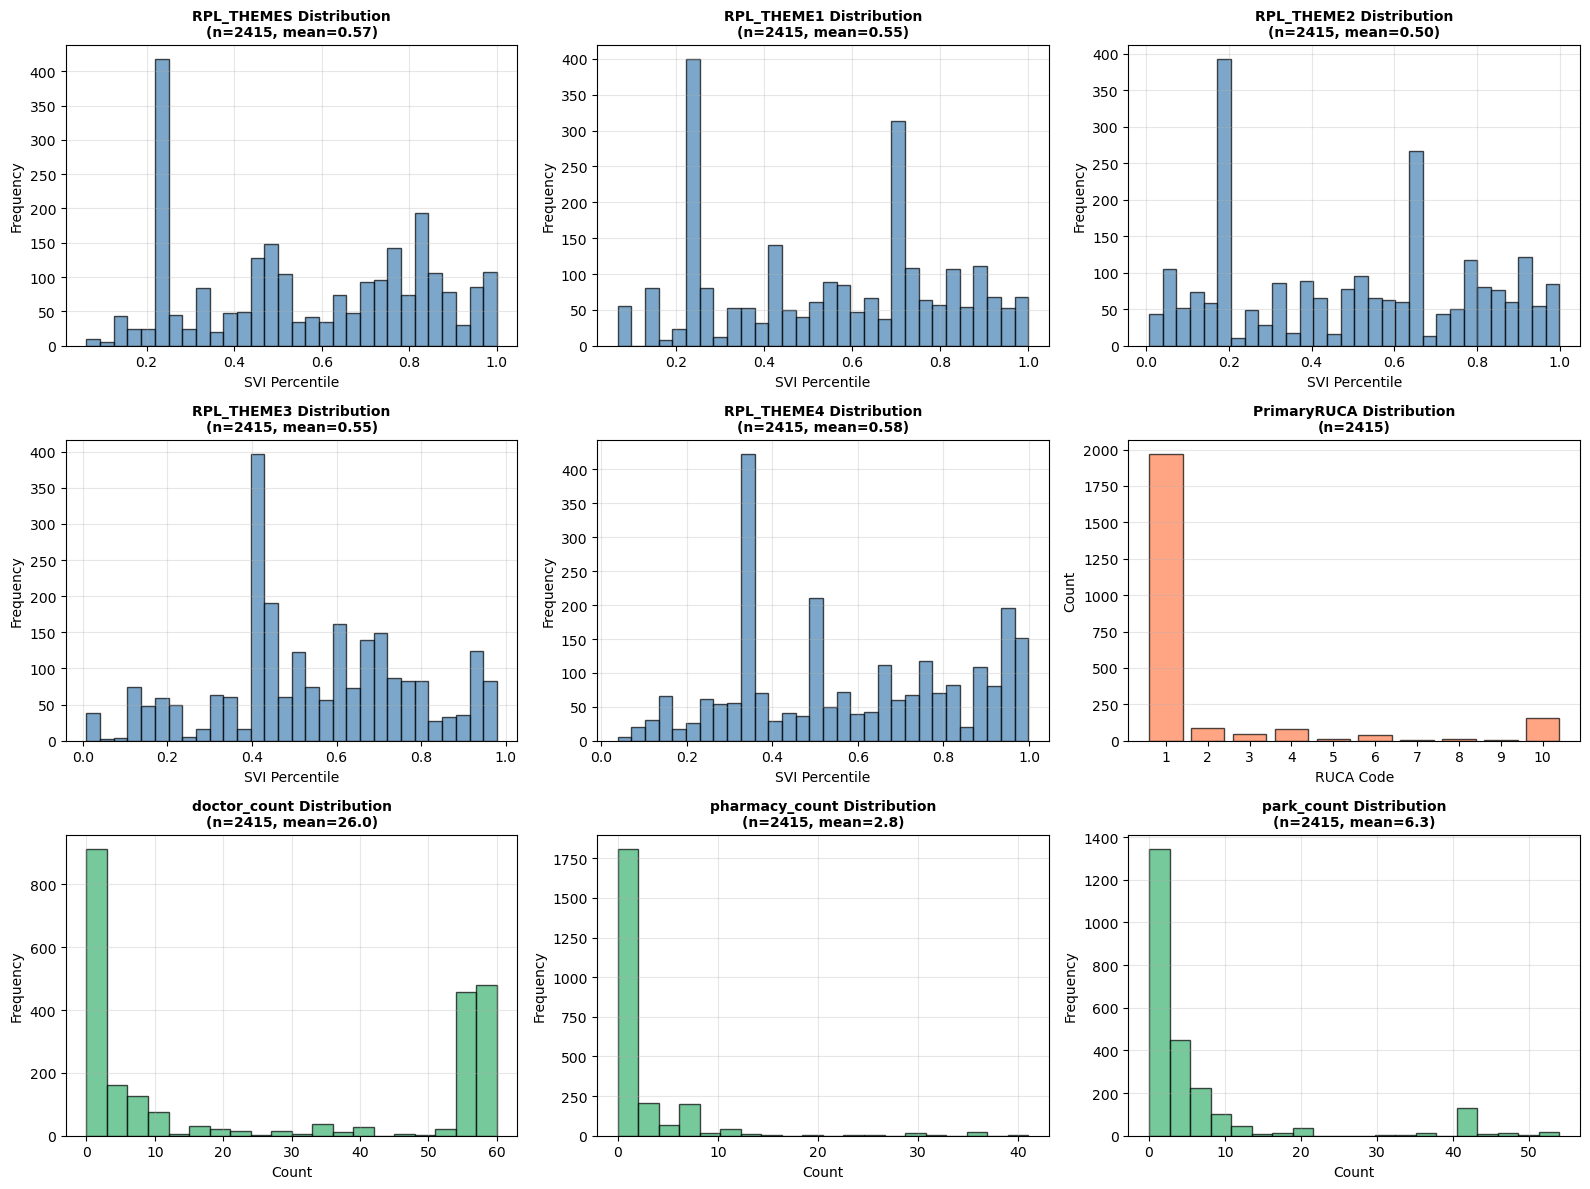


Saved geographic and SVI distributions summary visualization

CLUSTER DISTRIBUTION: PARTICIPANTS PER CLUSTER

Total unique clusters: 10
Total participants: 2859
Mean participants per cluster: 241.50
Median participants per cluster: 31
Max participants in a cluster: 1730
Min participants in a cluster: 2


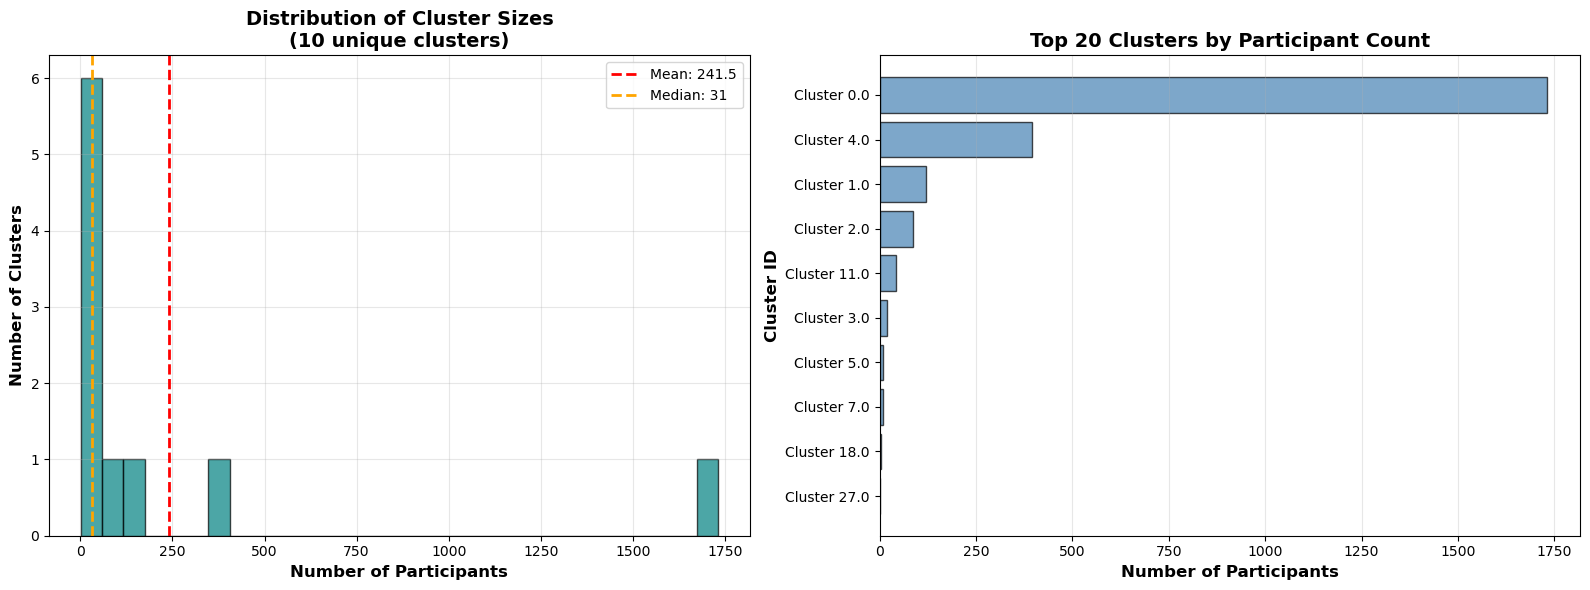


Saved cluster distribution visualization

Top 10 clusters with most participants:
  Cluster 0.0: 1730 participants
  Cluster 4.0: 395 participants
  Cluster 1.0: 120 participants
  Cluster 2.0: 86 participants
  Cluster 11.0: 42 participants
  Cluster 3.0: 20 participants
  Cluster 5.0: 8 participants
  Cluster 7.0: 8 participants
  Cluster 18.0: 4 participants
  Cluster 27.0: 2 participants

GEOGRAPHIC AND SVI SUMMARY STATISTICS
                    count       mean        std     min     25%      50%       75%      max
RPL_THEMES         2415.0   0.566948   0.258968  0.0626  0.3170   0.5607   0.80555   0.9998
RPL_THEME1         2415.0   0.552337   0.255776  0.0665  0.2641   0.5762   0.73290   0.9998
RPL_THEME2         2415.0   0.497308   0.292215  0.0069  0.1918   0.5227   0.74620   0.9995
RPL_THEME3         2415.0   0.549207   0.225157  0.0086  0.4255   0.5280   0.71210   0.9786
RPL_THEME4         2415.0   0.584951   0.258274  0.0387  0.3496   0.5608   0.81280   0.9979
doctor_count 

,Variable_Decoded,Variable,Count,Null_Count,Percent_Non-Null
0,Participant ID,pid,2859,0,100.00
24,sds-2-social-leisure-disruption,sds-2-social-leisure-disruption,2859,0,100.00
23,sds-1-work-school-disruption,sds-1-work-school-disruption,2859,0,100.00
22,SCL-9 Global Score,scl-avg-global-score,2859,0,100.00
25,sds-3-home-family-disruption,sds-3-home-family-disruption,2859,0,100.00
...,...,...,...,...,...
9,Gender: Other,gender_5.0,7,0,0.24
73,Primaryruca: Small Town Core,PrimaryRUCA_7.0,7,0,0.24
43,Sexuality: Unknown,sexuality_999.0,5,0,0.17
8,Gender: Transgender (F to M),gender_4.0,4,0,0.14


In [493]:
# Clean merged dataframe with location data
if 'merged_df' in locals():
    print("Original merged_df shape:", merged_df.shape)
    
    # Identify duplicate columns (columns that existed in X_basic_plus_clin_sdh)
    original_cols = set(X_basic_plus_clin_sdh.columns)
    location_cols = set(merged_df.columns) - original_cols
    duplicate_cols = location_cols.intersection(original_cols)
    
    print(f"\nDuplicate columns to drop: {len(duplicate_cols)}")
    if len(duplicate_cols) > 0:
        print(f"Examples: {list(duplicate_cols)[:10]}")
    
    # Also drop account_id (duplicate of pid)
    cols_to_drop = list(duplicate_cols) + ['account_id']
    cols_to_drop = [col for col in cols_to_drop if col in merged_df.columns]
    
    # Drop duplicate columns
    X_location_clean = merged_df.drop(columns=cols_to_drop, errors='ignore')
    print(f"\nAfter dropping duplicates: {X_location_clean.shape}")
    
    # Remove columns with 0 or 1 unique values (causes R regression errors)
    single_value_cols = [col for col in X_location_clean.columns if X_location_clean[col].nunique() <= 1]
    if len(single_value_cols) > 0:
        print(f"\nRemoving {len(single_value_cols)} columns with 0 or 1 unique values:")
        print(f"  {single_value_cols}")
        X_location_clean = X_location_clean.drop(columns=single_value_cols)
        print(f"After removing constant columns: {X_location_clean.shape}")
    
    # Identify categorical location columns to encode
    categorical_location_cols = []
    
    # Check which categorical columns exist
    potential_categorical = ['PrimaryRUCA', 'SecondaryRUCA', 'STATEFP']
    for col in potential_categorical:
        if col in X_location_clean.columns:
            categorical_location_cols.append(col)
            print(f"\n{col} unique values: {X_location_clean[col].nunique()}")
    
    # One-hot encode categorical location variables
    if len(categorical_location_cols) > 0:
        print(f"\nOne-hot encoding: {categorical_location_cols}")
        X_location_encoded = one_hot_encode(df=X_location_clean, cols2encode=categorical_location_cols)
        
        # Drop original categorical columns and add encoded versions
        X_location_final = X_location_clean.drop(columns=categorical_location_cols)
        X_location_final = pd.concat([X_location_final, X_location_encoded], axis=1)
        
        print(f"\nFinal shape after encoding: {X_location_final.shape}")
    else:
        print("\nNo categorical location columns found to encode")
        X_location_final = X_location_clean
    
    # Save final dataset
    X_location_final.to_csv(out_folder + "X_basic_plus_clin_sdh_location_encoded.csv")
    print("\nSaved X_basic_plus_clin_sdh_location_encoded.csv")
    

    # Display column summary
    print(f"\nFinal dataset columns: {X_location_final.shape[1]}")
    location_specific_cols = [col for col in X_location_final.columns if col not in X_basic_plus_clin_sdh.columns]
    print(f"Location-specific columns added: {len(location_specific_cols)}")
    print(f"Examples: {location_specific_cols[:20]}")
    
    # Create graphic summary of geographic and SVI distributions
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("\n" + "="*80)
    print("GEOGRAPHIC AND SVI DISTRIBUTION SUMMARY")
    print("="*80)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. SVI THEMES DISTRIBUTIONS (histograms)
    svi_cols = ['RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']
    available_svi = [col for col in svi_cols if col in X_location_final.columns]
    
    if available_svi:
        for idx, col in enumerate(available_svi, 1):
            ax = plt.subplot(3, 3, idx)
            data = X_location_final[col].dropna()
            ax.hist(data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.2f})', fontsize=10, fontweight='bold')
            ax.set_xlabel('SVI Percentile')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
    
    # 2. RUCA DISTRIBUTIONS (if available before encoding)
    # Note: These are one-hot encoded in X_location_final, so show summary
    ruca_cols = ['PrimaryRUCA', 'SecondaryRUCA']
    for col in ruca_cols:
        if col in merged_df.columns:  # Check in original merged_df before encoding
            ax = plt.subplot(3, 3, len(available_svi) + ruca_cols.index(col) + 1)
            ruca_data = merged_df[col].dropna().value_counts().sort_index()
            ax.bar(range(len(ruca_data)), ruca_data.values, color='coral', alpha=0.7, edgecolor='black')
            ax.set_xticks(range(len(ruca_data)))
            ax.set_xticklabels(ruca_data.index.astype(int))
            ax.set_title(f'{col} Distribution\n(n={ruca_data.sum()})', fontsize=10, fontweight='bold')
            ax.set_xlabel('RUCA Code')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3, axis='y')
    
    # 3. POI COUNTS DISTRIBUTIONS
    poi_cols = ['doctor_count', 'pharmacy_count', 'hospital_count', 'park_count', 'bus_station_count', 'supermarket_count']
    available_poi = [col for col in poi_cols if col in X_location_final.columns]
    
    for idx, col in enumerate(available_poi[:3]):  # Show first 3
        ax = plt.subplot(3, 3, len(available_svi) + 2 + idx)
        data = X_location_final[col].dropna()
        ax.hist(data, bins=20, color='mediumseagreen', alpha=0.7, edgecolor='black')
        ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.1f})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Count')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    
    # 4. REMAINING POI COUNTS (if space)
    for idx, col in enumerate(available_poi[3:]):
        if len(available_svi) + 2 + 3 + idx < 10:
            ax = plt.subplot(3, 3, len(available_svi) + 2 + 3 + idx)
            data = X_location_final[col].dropna()
            ax.hist(data, bins=20, color='mediumpurple', alpha=0.7, edgecolor='black')
            ax.set_title(f'{col} Distribution\n(n={len(data)}, mean={data.mean():.1f})', fontsize=10, fontweight='bold')
            ax.set_xlabel('Count')
            ax.set_ylabel('Frequency')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(out_folder + "geographic_svi_distributions_summary.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nSaved geographic and SVI distributions summary visualization")
    
    # Create cluster distribution visualization
    if 'cluster' in X_location_final.columns:
        print("\n" + "="*80)
        print("CLUSTER DISTRIBUTION: PARTICIPANTS PER CLUSTER")
        print("="*80)
        
        # Count participants per cluster
        cluster_counts = X_location_final['cluster'].value_counts().sort_index()
        
        print(f"\nTotal unique clusters: {len(cluster_counts)}")
        print(f"Total participants: {len(X_location_final)}")
        print(f"Mean participants per cluster: {cluster_counts.mean():.2f}")
        print(f"Median participants per cluster: {cluster_counts.median():.0f}")
        print(f"Max participants in a cluster: {cluster_counts.max()}")
        print(f"Min participants in a cluster: {cluster_counts.min()}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Histogram of participants per cluster
        ax1 = axes[0]
        ax1.hist(cluster_counts.values, bins=30, color='teal', alpha=0.7, edgecolor='black')
        ax1.set_xlabel('Number of Participants', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Number of Clusters', fontsize=12, fontweight='bold')
        ax1.set_title(f'Distribution of Cluster Sizes\n({len(cluster_counts)} unique clusters)', 
                      fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.axvline(cluster_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cluster_counts.mean():.1f}')
        ax1.axvline(cluster_counts.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {cluster_counts.median():.0f}')
        ax1.legend()
        
        # Top 20 clusters by participant count
        ax2 = axes[1]
        top_clusters = cluster_counts.nlargest(20)
        ax2.barh(range(len(top_clusters)), top_clusters.values, color='steelblue', alpha=0.7, edgecolor='black')
        ax2.set_yticks(range(len(top_clusters)))
        ax2.set_yticklabels([f'Cluster {c}' for c in top_clusters.index])
        ax2.set_xlabel('Number of Participants', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cluster ID', fontsize=12, fontweight='bold')
        ax2.set_title('Top 20 Clusters by Participant Count', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.invert_yaxis()
        
        plt.tight_layout()
        plt.savefig(out_folder + "cluster_distribution_summary.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nSaved cluster distribution visualization")
        
        # Show some cluster statistics
        print("\nTop 10 clusters with most participants:")
        top_10 = cluster_counts.nlargest(10)
        for cluster_id, count in top_10.items():
            print(f"  Cluster {cluster_id}: {count} participants")
    
    # Summary statistics for geographic/SVI variables
    print("\n" + "="*80)
    print("GEOGRAPHIC AND SVI SUMMARY STATISTICS")
    print("="*80)
    
    summary_vars = available_svi + available_poi
    if summary_vars:
        summary_df = X_location_final[summary_vars].describe().T
        print(summary_df.to_string())
        
        # Show missing data
        print("\nMissing Data:")
        missing_geo = X_location_final[summary_vars].isna().sum()
        print(missing_geo[missing_geo > 0].to_string() if (missing_geo > 0).any() else "No missing data")

    # Change the count per participant calculation for cluster, to be count per diary, and count of participants per cluster
    # ToDo: check if PID is participant or diary

    # Create observation counts dataframe
    print("\n" + "="*80)
    print("OBSERVATION COUNTS FOR EACH VARIABLE")
    print("="*80)
    
    # Function to count observations correctly based on variable type
    def get_observation_count(series):
        """
        For boolean/binary variables (0/1), count the number of 1s.
        For other variables, count non-null values.
        """
        unique_vals = series.dropna().unique()
        # Check if it's a boolean/binary variable (only contains 0 and 1)
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1, 0.0, 1.0}):
            return (series == 1).sum()
        else:
            return series.notna().sum()
    
    # Calculate counts for each variable
    non_null_counts = []
    for col in X_location_final.columns:
        non_null_counts.append(get_observation_count(X_location_final[col]))
    
    variable_counts = pd.DataFrame({
        'Variable': X_location_final.columns,
        'Count': non_null_counts,
        'Null_Count': X_location_final.isna().sum().values,
        'Total_Rows': len(X_location_final),
        'Percent_Non-Null': (np.array(non_null_counts) / len(X_location_final) * 100).round(2)
    })
    
    # Add decoded variable names for better readability
    # Use a safe wrapper to handle any decoding errors
    def safe_decode(var_name):
        try:
            return decode_variable_name(var_name)
        except Exception as e:
            # If decoding fails, return the original variable name
            return var_name
    
    variable_counts['Variable_Decoded'] = variable_counts['Variable'].apply(safe_decode)
    
    # Sort by non-null count descending
    variable_counts = variable_counts.sort_values('Count', ascending=False)
    
    print(f"\nVariable counts summary:")
    print(variable_counts[['Variable_Decoded', 'Variable', 'Count', 'Null_Count', 'Percent_Non-Null']].to_string(index=False))
    
    # Save counts to CSV
    variable_counts.to_csv(out_folder + "X_location_encoded_variable_counts.csv", index=False)
    print(f"\nSaved variable counts to X_location_encoded_variable_counts.csv")
    
    # Display the variable counts dataframe with decoded names
    display(variable_counts[['Variable_Decoded', 'Variable', 'Count', 'Null_Count', 'Percent_Non-Null']])
    
else:
    print("No merged_df found. Please run the previous cell first.")

### Create Stratification Variables
Create meaningful stratification variables for cluster-adjusted analyses:
- **Urban/Rural Categories**: From RUCA codes
- **SVI Vulnerability Levels**: Low/Medium/High based on RPL_THEMES percentiles
- **Healthcare Access**: Based on combined doctor/pharmacy/hospital counts

In [494]:
# Create stratification variables by combining RUCA, REPL, SVI, Healthcare & Resource Access, and Cluster variables into meaningful categories for stratified analyses in R. This will allow us to analyze WER and coherence across different geographic and social vulnerability contexts.
import re


if 'X_location_final' in locals():
    print("="*80)
    print("CREATING STRATIFICATION VARIABLES")
    print("="*80)
    
    X_stratified = X_location_final.copy()
    
    # 1. URBAN/RURAL STRATIFICATION FROM RUCA CODES
    # RUCA codes: 1-3 = Urban, 4-6 = Suburban, 7-10 = Rural
    # ToDo: Erin got these RUCA bins from a Google suggestion on what's been used before
    # https://doh.wa.gov/sites/default/files/legacy/Documents/1500/RUCAGuide.pdf

    print("\n1. Urban/Rural Classification from RUCA Codes")
    print("-" * 80)
    
    if 'PrimaryRUCA' in merged_df.columns:

        
        def classify_urban_rural(ruca_code):
            """Classify RUCA code into urban/suburban/rural categories."""
            if pd.isna(ruca_code):
                return 'Unknown'
            s = str(ruca_code).strip()
            # grab first numeric portion (integer or float, optionally negative)
            m = re.search(r'(-?\d+(?:\.\d+)?)', s)
            if not m:
                return 'Unknown'
            try:
                val = float(m.group(1))
            except ValueError:
                return 'Unknown'
        
            if val <= 1:
                return 'UrbanCore'
            elif val <= 3:
                return 'Suburban'
            elif val <= 6:
                return 'LargeRural'
            elif val <= 10:
                return 'SmallTownRural'
            else:
                return 'Rural'

        X_stratified['urban_rural_category'] = merged_df['PrimaryRUCA'].apply(classify_urban_rural)
        # create the categorical column

        # one‑hot encode it and join back to X_stratified
        dummies = pd.get_dummies(X_stratified['urban_rural_category'],
                                 prefix='urban_rural',
                                 dummy_na=False)   # drop NaN column if you don’t want one
        
        # either overwrite X_stratified or create a new dataframe
        X_stratified = pd.concat([X_stratified, dummies], axis=1)
        print(f"Created urban/rural categories and one-hot encoded them. New shape: {X_stratified.shape}")
        print(X_stratified.head())

        # Also create binary urban vs non-urban
        X_stratified['is_urban'] = (merged_df['PrimaryRUCA'] <= 3).astype(float)
        
        print("Distribution of Urban/Rural Categories:")
        print(X_stratified['urban_rural_category'].value_counts())
        print(f"\nUrban participants: {X_stratified['is_urban'].sum():.0f} ({X_stratified['is_urban'].mean()*100:.1f}%)")
    else:
        print("WARNING: PrimaryRUCA not found in merged_df, skipping urban/rural classification")

    
    # 2. SVI VULNERABILITY STRATIFICATION
    # RPL_THEMES: 0-0.33 = Low vulnerability, 0.33-0.66 = Medium, 0.66-1.0 = High
    # ToDo: Base theses off SVI research literature, want to make sure informed categorizations
    # https://hqin.org/wp-content/uploads/2022/09/Social-Vulnerability-Index-Toolkit.pdf
    print("\n2. SVI Vulnerability Levels")
    print("-" * 80)
    
    if 'RPL_THEMES' in X_location_final.columns:
        def classify_svi_level(svi_score):
            """Classify SVI score into low/medium/high vulnerability"""
            if pd.isna(svi_score):
                return 'Unknown'
            elif svi_score < 0.33:
                return 'Low Vulnerability'
            elif svi_score < 0.66:
                return 'Medium Vulnerability'
            else:
                return 'High Vulnerability'
        
        X_stratified['svi_category'] = X_location_final['RPL_THEMES'].apply(classify_svi_level)
        
        # Also create binary high vulnerability indicator
        X_stratified['high_svi'] = (X_location_final['RPL_THEMES'] >= 0.66).astype(float)
        
        print("Distribution of SVI Categories:")
        print(X_stratified['svi_category'].value_counts())
        print(f"\nHigh vulnerability areas: {X_stratified['high_svi'].sum():.0f} ({X_stratified['high_svi'].mean()*100:.1f}%)")
        
        # Also create SVI theme-specific categorizations
        svi_themes = ['RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']
        available_themes = [theme for theme in svi_themes if theme in X_location_final.columns]
        
        for theme in available_themes:
            theme_name = theme.replace('RPL_THEME', 'svi_theme')
            X_stratified[f'{theme_name}_high'] = (X_location_final[theme] >= 0.66).astype(float)
    else:
        print("WARNING: RPL_THEMES not found, skipping SVI classification")
    
    # 3. HEALTHCARE ACCESS STRATIFICATION
    # Combine doctor, pharmacy, and hospital counts
    # ToDo: Don't combine these for now. Run analyses separately with just counts. There are issues with combining counts of different types of POIs
    # Could also turn into PCA - Principal Component Analysis - to create composite access score. Summarize multiple access indicators
    print("\n3. Healthcare Access Levels")
    print("-" * 80)
    
    healthcare_cols = ['doctor_count', 'pharmacy_count', 'hospital_count']
    available_healthcare = [col for col in healthcare_cols if col in X_location_final.columns]
    
    if available_healthcare:
        # Create composite healthcare access score
        X_stratified['healthcare_access_score'] = X_location_final[available_healthcare].sum(axis=1)
        
        # Categorize into tertiles: Low/Medium/High access
        healthcare_tertiles = X_stratified['healthcare_access_score'].quantile([0.33, 0.66])
        
        def classify_healthcare_access(score):
            """Classify healthcare access score into tertiles"""
            if pd.isna(score):
                return 'Unknown'
            elif score <= healthcare_tertiles.iloc[0]:
                return 'Low Healthcare Access'
            elif score <= healthcare_tertiles.iloc[1]:
                return 'Medium Healthcare Access'
            else:
                return 'High Healthcare Access'
        
        X_stratified['healthcare_access_category'] = X_stratified['healthcare_access_score'].apply(classify_healthcare_access)
        
        # Also create binary low access indicator
        X_stratified['low_healthcare_access'] = (X_stratified['healthcare_access_score'] <= healthcare_tertiles.iloc[0]).astype(float)
        
        print(f"Healthcare tertile thresholds: Low<={healthcare_tertiles.iloc[0]:.1f}, Medium<={healthcare_tertiles.iloc[1]:.1f}")
        print("\nDistribution of Healthcare Access Categories:")
        print(X_stratified['healthcare_access_category'].value_counts())
        print(f"\nLow healthcare access: {X_stratified['low_healthcare_access'].sum():.0f} ({X_stratified['low_healthcare_access'].mean()*100:.1f}%)")
    else:
        print("WARNING: No healthcare count variables found, skipping healthcare access classification")
    
    # 4. RESOURCE ACCESS STRATIFICATION
    # Combine supermarket, park, bus station counts
    # ToDo: just do these with counts? Don't combine just yet
    print("\n4. Community Resource Access Levels")
    print("-" * 80)
    
    resource_cols = ['supermarket_count', 'park_count', 'bus_station_count']
    available_resources = [col for col in resource_cols if col in X_location_final.columns]
    
    if available_resources:
        # Create composite resource access score
        X_stratified['resource_access_score'] = X_location_final[available_resources].sum(axis=1)
        
        # Categorize into tertiles
        resource_tertiles = X_stratified['resource_access_score'].quantile([0.33, 0.66])
        
        def classify_resource_access(score):
            """Classify resource access score into tertiles"""
            if pd.isna(score):
                return 'Unknown'
            elif score <= resource_tertiles.iloc[0]:
                return 'Low Resource Access'
            elif score <= resource_tertiles.iloc[1]:
                return 'Medium Resource Access'
            else:
                return 'High Resource Access'
        
        X_stratified['resource_access_category'] = X_stratified['resource_access_score'].apply(classify_resource_access)
        
        # Also create binary low access indicator
        X_stratified['low_resource_access'] = (X_stratified['resource_access_score'] <= resource_tertiles.iloc[0]).astype(float)
        
        print(f"Resource tertile thresholds: Low<={resource_tertiles.iloc[0]:.1f}, Medium<={resource_tertiles.iloc[1]:.1f}")
        print("\nDistribution of Resource Access Categories:")
        print(X_stratified['resource_access_category'].value_counts())
        print(f"\nLow resource access: {X_stratified['low_resource_access'].sum():.0f} ({X_stratified['low_resource_access'].mean()*100:.1f}%)")
    else:
        print("WARNING: No resource count variables found, skipping resource access classification")
    
    # 5. COMBINED STRATIFICATIONS
    # Create useful combinations for interaction analyses
    print("\n5. Combined Stratification Variables")
    print("-" * 80)
    
    if 'urban_rural_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
        X_stratified['urban_high_svi'] = ((X_stratified['urban_rural_category'] == 'Urban') & 
                                           (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        X_stratified['rural_high_svi'] = ((X_stratified['urban_rural_category'] == 'Rural') & 
                                           (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        
        print(f"Urban + High SVI: {X_stratified['urban_high_svi'].sum():.0f} participants")
        print(f"Rural + High SVI: {X_stratified['rural_high_svi'].sum():.0f} participants")
    
    if 'healthcare_access_category' in X_stratified.columns and 'svi_category' in X_stratified.columns:
        X_stratified['low_healthcare_high_svi'] = ((X_stratified['healthcare_access_category'] == 'Low Healthcare Access') & 
                                                    (X_stratified['svi_category'] == 'High Vulnerability')).astype(float)
        
        print(f"Low Healthcare + High SVI: {X_stratified['low_healthcare_high_svi'].sum():.0f} participants")


    # Remove columns
    X_stratified = X_stratified.drop(columns=['svi_category', 'park_count', 'high_svi', 
                                              'bus_station_count', 'supermarket_count', 'doctor_count', 'pharmacy_count', 'park_count',
                                              'cluster', 
                                              'is_urban', 
                                              # 'urban_rural_category'
                                              'sds-1-work-school-disruption', 'sds-2-social-leisure-disruption', 'sds-3-home-family-disruption', 
                                              'sds-4-school-work-missed', 'sds-5-less-productive-days', 'sds-6-2t-worked-for-other-reasons'
                                              #ToDo: question about why dropping SNR?
                                              'snr',
                                              'PrimaryRUCA_10.0', 'PrimaryRUCA_1.0', 'PrimaryRUCA_2.0', 'PrimaryRUCA_3.0', 'PrimaryRUCA_4.0',
                                              'PrimaryRUCA_5.0', 'PrimaryRUCA_6.0', 'PrimaryRUCA_7.0', 'PrimaryRUCA_8.0',
                                              'PrimaryRUCA_9.0', 'PrimaryRUCA_nan',
                                              'urban_high_svi', 'rural_high_svi', 'low_healthcare_high_svi',
                                              'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES'], errors='ignore')



# In your Python notebook, before saving X_stratified:
columns_to_drop = [
    # Drop urban_rural boolean dummies (keep urban_rural_category)
    'urban_rural_LargeRural',
    'urban_rural_SmallTownRural', 
    'urban_rural_Suburban',
    'urban_rural_Unknown',
    'urban_rural_UrbanCore',
    
    # Optionally drop redundant healthcare/resource access boolean indicators
    # (keep the _category and _score versions)
    'low_healthcare_access',
    'low_resource_access',
    # Drop the sheehan disability scale subscores, have sds_total for overall disability level, and the individual subscores are highly correlated with each other and with total, so not adding much value and causing multicollinearity issues in regression analyses
    'sds-1-work-school-disruption', 
    'sds-2-social-leisure-disruption', 
    'sds-3-home-family-disruption', 
    'sds-4-school-work-missed', 
    'sds-5-less-productive-days', 
    'sds-6-2t-worked-for-other-reasons', 

    #Drop the columns that came back as high VIF, which was the self reported substance use
    'opioids-opiates_0.0',  # VIF = 25.22 (binary flag: 0/1)
    'substance_marijuana_0.0',  # VIF = 12.58
    'substance_alcohol_0.0',  # VIF = 12.55
    'substance_stimulant_0.0',  # VIF = 15.22
    'substance_nicotine_0.0',  # VIF = 6.42
    'substance_psychoactive_0.0',  # VIF = 144.93
    'opioids-opiates',  
    'substance_marijuana',  
    'substance_alcohol',
    'substance_stimulant',
    'substance_nicotine',
    'substance_psychoactive',
    
    'SCL9_moderate', # VIF = 34
    'pred_mos' # dropping because replaced with AMOS. AMOS and pred_mos are pretty much the same thing, Changye
    

]

X_stratified = X_stratified.drop(columns=columns_to_drop, errors='ignore')

# SAVE STRATIFIED DATASET
print("\n" + "="*80)
print("SAVING STRATIFIED DATASET")
print("="*80)

X_stratified.to_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv")
print(f"\nSaved stratified dataset: {X_stratified.shape}")
print(f"New stratification columns added: {len(X_stratified.columns) - len(X_location_final.columns)}")

# Display summary of all stratification variables
stratification_vars = [col for col in X_stratified.columns if col not in X_location_final.columns]
print(f"\nStratification variables created ({len(stratification_vars)}):")
for var in stratification_vars:
    print(f"  - {var}")


CREATING STRATIFICATION VARIABLES

1. Urban/Rural Classification from RUCA Codes
--------------------------------------------------------------------------------
Created urban/rural categories and one-hot encoded them. New shape: (2859, 83)
    pid  race_2.0  race_4.0  race_5.0  race_6.0  race_999.0  gender_1.0  \
0  1870         0         0         0         0           0           0   
1  1870         0         0         0         0           0           0   
2  1553         0         0         0         1           0           0   
3  1788         0         0         0         1           0           0   
4  2319         0         0         0         0           0           1   

   gender_3.0  gender_4.0  gender_5.0  ...  PrimaryRUCA_7.0  PrimaryRUCA_8.0  \
0           0           0           0  ...                0                0   
1           0           0           0  ...                0                0   
2           0           0           0  ...                0         

In [495]:
# Multiple Hypothesis Testing Correction + VIF + R-like clustered regressions
# For file: X_basic_plus_clin_sdh_location_stratified.csv

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from patsy.builtins import Q

# Load stratified data
X_stratified = pd.read_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv", index_col=0)

print("=" * 80)
print("MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. VIF ANALYSIS - keep numeric-only VIF diagnostics
# ============================================================================
print("\n1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("-" * 80)

numeric_cols = [col for col in X_stratified.select_dtypes(include=[np.number]).columns if col != "pid"]
X_for_vif = X_stratified[numeric_cols].copy()

vif_data = pd.DataFrame()
vif_data["Variable"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]

def interpret_vif(vif):
    if vif < 5:
        return "OK"
    return "Concerning" if vif < 10 else "SERIOUS"

vif_data["Assessment"] = vif_data["VIF"].apply(interpret_vif)
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string())
vif_data.to_csv(out_folder + "vif_stratified_analysis.csv", index=False)
print(f"\nVIF results saved to: {out_folder}vif_stratified_analysis.csv")

# Calculate the multicollinearity between the SERIOUS VIF variables, to understand which ones are most correlated with each other.
high_vif_features = vif_data.loc[vif_data["VIF"] >= 10, "Variable"].tolist()
print("high_vif_features:", high_vif_features)

if not high_vif_features:
    raise RuntimeError("No VIF >=10 variables")

# Use the same dataframe used for VIF computation
common = [f for f in high_vif_features if f in X_stratified.columns]
print("common high-VIF cols in X_stratified:", common)

if not common:
    raise RuntimeError("No overlap between VIF variables and X_stratified columns")

numeric_df = X_stratified[common].select_dtypes(include="number")
corr_high_vif = numeric_df.corr()
print("\nCorrelation matrix for high-VIF numeric features:")
print(corr_high_vif)


# ============================================================================
# 2. R-like regression with formula, categorical handling, clustered SE by pid
# ============================================================================
print("\n\n2. REGRESSION MODELS FOR BOTH OUTCOMES (R-LIKE SPECS + CLUSTERED SE)")
print("-" * 80)

# Auto-detect available outcome columns
wer_col = next((c for c in ["WER", "wer", "log_wer", "Y_WER"] if c in X_stratified.columns), None)
coh_col = next((c for c in ["sentCoherenceSentBertCumulativeCentroid", "Y_COH"] if c in X_stratified.columns), None)
outcomes = [col for col in [wer_col, coh_col] if col is not None]

results_list = []
for outcome_name in outcomes:
    # Exclude all outcome aliases (not just the current one)
    exclude = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}

    predictors = [c for c in X_stratified.columns if c not in exclude]

    # Build R-like formula terms, handling special chars and categoricals
    terms = []
    for c in predictors:
        qc = f'Q("{c}")'
        if pd.api.types.is_object_dtype(X_stratified[c]) or isinstance(X_stratified[c].dtype, pd.CategoricalDtype):
            terms.append(f"C({qc})")
        else:
            terms.append(qc)

    formula = f'Q("{outcome_name}") ~ ' + ' + '.join(terms)

    print(f"\n\nOUTCOME: {outcome_name}")
    print("=" * 80)
    print("Formula:")
    print(formula[:400] + ("..." if len(formula) > 400 else ""))

    # Match R inference: clustered robust SE by pid
    model = smf.ols(formula=formula, data=X_stratified).fit(
        cov_type="cluster",
        cov_kwds={"groups": X_stratified["pid"], "use_correction": True}
    )

    coef_table = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Std_Error": model.bse.values,
        "t_statistic": model.tvalues.values,
        "p_value": model.pvalues.values
    })

    # Multiple-testing correction excluding intercept
    const_mask = coef_table["Variable"].isin(["Intercept", "const"])
    coef_table_for_correction = coef_table.loc[~const_mask].copy()

    reject_bonf, p_bonf, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="bonferroni")
    reject_fdr, p_fdr, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="fdr_bh")

    coef_table_for_correction["p_bonferroni"] = p_bonf
    coef_table_for_correction["bonferroni_significant"] = reject_bonf
    coef_table_for_correction["p_fdr"] = p_fdr
    coef_table_for_correction["fdr_significant"] = reject_fdr

    if const_mask.any():
        const_row = coef_table.loc[const_mask].copy()
        const_row["p_bonferroni"] = np.nan
        const_row["bonferroni_significant"] = False
        const_row["p_fdr"] = np.nan
        const_row["fdr_significant"] = False
        coef_table_out = pd.concat([const_row, coef_table_for_correction], ignore_index=True)
    else:
        coef_table_out = coef_table_for_correction.copy()

    filename = out_folder + f"regression_stratified_{outcome_name}.csv"
    coef_table_out.to_csv(filename, index=False)
    print(f"Regression results saved to: {filename}")

    print(f"Model R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print("Significant variables (FDR corrected, alpha=0.05):")
    sig_vars = coef_table_out[coef_table_out["fdr_significant"] == True]
    if len(sig_vars) > 0:
        print(sig_vars[["Variable", "Coefficient", "p_value", "p_fdr"]].to_string(index=False))
    else:
        print("   None")

    results_list.append(coef_table_out)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"All results saved to: {out_folder}")


MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS

1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
                    Variable        VIF  Assessment
22              dx_group_smi  41.241036     SERIOUS
19         hpsvq-total-score  32.839688     SERIOUS
15                      AMOS  18.647291     SERIOUS
13                     Y_WER  12.747984     SERIOUS
28                 PHQ9_high  12.384138     SERIOUS
35     employment-status_1.0  11.380414     SERIOUS
14                     Y_COH  11.217244     SERIOUS
30                  SDS_High   9.290219  Concerning
29                 SCL9_High   8.202838  Concerning
47     resource_access_score   5.332931  Concerning
42           svi_theme1_high   4.907717          OK
46   healthcare_access_score   4.844503          OK
44           svi_theme3_high   4.163261          OK
21  phq9-9-suicidal-thoughts   3.748668          OK
5                 gender_1.0   3.706442 

In [496]:
# Add a cell that compares the regression_stratified_log_wer.csv. "/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv"), and 
# the regression calculated in sandwich_script.r, "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv",
# to compare and see if we have the same columns,
# and same results for each variable and coefficient, standard error, and p-value. This will help us validate that our Python regression results are consistent with the R results, 
# and that the multiple testing correction is being applied correctly in both analyses. 
# We can also check if the same variables are significant in both analyses after correction.

# Cell 89: Compare Python vs R stratified WER regression outputs

import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.multitest import multipletests

# ---- Paths ----
py_path = "/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv"
r_path = "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv"

# ---- Load ----
py = pd.read_csv(py_path)
r = pd.read_csv(r_path)

# ---- Standardize schema ----
py = py.rename(columns={
    "Variable": "term_py",
    "Coefficient": "coef_py",
    "Std_Error": "se_py",
    "p_value": "p_py",
    "p_bonferroni": "p_bonf_py",
    "bonferroni_significant": "sig_bonf_py",
    "p_fdr": "p_fdr_py",
    "fdr_significant": "sig_fdr_py",
})

r = r.rename(columns={
    r.columns[0]: "term_r_raw",   # first unnamed column in R output
    "Estimate": "coef_r",
    "Std. Error": "se_r",
    "Pr(>|t|)": "p_r",
})

# ---- Normalize variable names so they can be matched ----
def normalize_term(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip().strip('"')
    if t in {"(Intercept)", "const"}:
        return "const"
    
    # Handle Python's C(Q(...))[T.Category] format
    if "[T." in t:
        # e.g., C(Q("urban_rural_category"))[T.SmallTownRural]
        var_part = t.split('[')[0]  # C(Q("urban_rural_category"))
        cat_part = t.split('[T.')[1].rstrip(']')  # SmallTownRural
        var_name = var_part.replace('C(Q("', '').rstrip('")')  # Remove quotes and parens
        return var_name + cat_part
    
    # Handle plain Q("variable_name") format
    if t.startswith('Q("') and t.endswith('")'):
        # Extract the variable name from Q("name")
        var_name = t[3:-2]  # Remove Q(" from start and ") from end
        return var_name.replace(".", "-")
    
    # R file uses dots in some names; Python file uses hyphens
    return t.replace(".", "-")

py["term_norm"] = py["term_py"].map(normalize_term)
r["term_norm"] = r["term_r_raw"].map(normalize_term)

# ---- Recompute multiple testing correction on R side (excluding intercept) ----
mask_r_tests = r["term_norm"].ne("const") & r["p_r"].notna()
r.loc[mask_r_tests, "p_bonf_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="bonferroni")[1]
r.loc[mask_r_tests, "p_fdr_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="fdr_bh")[1]
r["sig_bonf_r"] = r["p_bonf_r"] < 0.05
r["sig_fdr_r"] = r["p_fdr_r"] < 0.05

# ---- Merge and compare ----
cmp = py.merge(
    r[["term_norm", "term_r_raw", "coef_r", "se_r", "p_r", "p_bonf_r", "p_fdr_r", "sig_bonf_r", "sig_fdr_r"]],
    on="term_norm",
    how="outer",
)

cmp["in_python"] = cmp["term_py"].notna()
cmp["in_r"] = cmp["term_r_raw"].notna()
cmp["missing_in_one_file"] = ~(cmp["in_python"] & cmp["in_r"])

# Tolerances for "close"
tol_coef = 1e-6
tol_se = 1e-6
tol_p = 1e-6

def close_or_na(a, b, atol):
    return np.where(a.notna() & b.notna(), np.isclose(a, b, atol=atol, rtol=1e-4), pd.NA)

cmp["coef_close"] = close_or_na(cmp["coef_py"], cmp["coef_r"], tol_coef)
cmp["se_close"] = close_or_na(cmp["se_py"], cmp["se_r"], tol_se)
cmp["p_close"] = close_or_na(cmp["p_py"], cmp["p_r"], tol_p)
cmp["p_bonf_close"] = close_or_na(cmp["p_bonf_py"], cmp["p_bonf_r"], tol_p)
cmp["p_fdr_close"] = close_or_na(cmp["p_fdr_py"], cmp["p_fdr_r"], tol_p)

cmp["sig_bonf_match"] = np.where(
    cmp["sig_bonf_py"].notna() & cmp["sig_bonf_r"].notna(),
    cmp["sig_bonf_py"] == cmp["sig_bonf_r"],
    pd.NA
)
cmp["sig_fdr_match"] = np.where(
    cmp["sig_fdr_py"].notna() & cmp["sig_fdr_r"].notna(),
    cmp["sig_fdr_py"] == cmp["sig_fdr_r"],
    pd.NA
)

cmp["any_numeric_mismatch"] = (
    (cmp["coef_close"] == False)
    | (cmp["se_close"] == False)
    | (cmp["p_close"] == False)
    | (cmp["p_bonf_close"] == False)
    | (cmp["p_fdr_close"] == False)
)

cmp["any_sig_mismatch"] = (
    (cmp["sig_bonf_match"] == False)
    | (cmp["sig_fdr_match"] == False)
)

cmp["flag"] = np.select(
    [
        cmp["missing_in_one_file"],
        cmp["any_numeric_mismatch"],
        cmp["any_sig_mismatch"],
    ],
    [
        "missing_variable",
        "numeric_mismatch",
        "significance_mismatch",
    ],
    default="ok",
)

# ---- Output tables ----
comparison_table = cmp[[
    "term_norm", "term_py", "term_r_raw", "in_python", "in_r", "flag",
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close",
    "p_bonf_py", "p_bonf_r", "p_bonf_close", "sig_bonf_py", "sig_bonf_r", "sig_bonf_match",
    "p_fdr_py", "p_fdr_r", "p_fdr_close", "sig_fdr_py", "sig_fdr_r", "sig_fdr_match",
]].sort_values(["flag", "term_norm"])

flagged = comparison_table[comparison_table["flag"] != "ok"].copy()
summary = (
    comparison_table["flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="n_terms")
)

print("Summary of comparison:")
display(summary)

print("Flagged rows (missing vars or mismatches):")
display(flagged)

print("Full comparison table:")
display(comparison_table)

# Compact save cell
out_dir = "/edata/obdw/sandwich_analysis_data"
comparison_table.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_full.csv", index=False)
flagged.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv", index=False)
summary.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_summary.csv", index=False)

print("Saved:")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_full.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_summary.csv")



Summary of comparison:


,flag,n_terms
0,numeric_mismatch,45
1,missing_variable,21


Flagged rows (missing vars or mismatches):


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
0,AMOS,NaN,AMOS,False,True,missing_variable,NaN,-0.115399,<NA>,NaN,...,<NA>,NaN,True,<NA>,NaN,0.001013,<NA>,NaN,True,<NA>
1,Intercept,Intercept,NaN,True,False,missing_variable,0.893724,NaN,<NA>,1.758222,...,<NA>,False,NaN,<NA>,NaN,NaN,<NA>,False,NaN,<NA>
4,SCL9_High,NaN,SCL9_High,False,True,missing_variable,NaN,-0.068170,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.917437,<NA>,NaN,False,<NA>
7,all_types_drug_use,NaN,all_types_drug_use,False,True,missing_variable,NaN,0.015648,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.917437,<NA>,NaN,False,<NA>
8,all_types_drug_use_0-0,"Q(""all_types_drug_use_0.0"")",NaN,True,False,missing_variable,0.042696,NaN,<NA>,0.279987,...,<NA>,False,NaN,<NA>,0.986407,NaN,<NA>,False,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,svi_theme3_high,"Q(""svi_theme3_high"")",svi_theme3_high,True,True,numeric_mismatch,0.027442,-0.032215,False,0.177752,...,True,False,False,True,0.986407,0.917437,False,False,False,True
61,svi_theme4_high,"Q(""svi_theme4_high"")",svi_theme4_high,True,True,numeric_mismatch,0.234343,0.140385,False,0.200486,...,True,False,False,True,0.510749,0.432382,False,False,False,True
62,urban_rural_categorySmallTownRural,"C(Q(""urban_rural_category""))[T.SmallTownRural]",urban_rural_categorySmallTownRural,True,True,numeric_mismatch,-0.481933,-0.120448,False,0.566550,...,True,False,False,True,0.620661,0.917437,False,False,False,True
63,urban_rural_categorySuburban,"C(Q(""urban_rural_category""))[T.Suburban]",urban_rural_categorySuburban,True,True,numeric_mismatch,-0.347610,-0.046851,False,0.592539,...,True,False,False,True,0.766483,0.917437,False,False,False,True


Full comparison table:


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
0,AMOS,NaN,AMOS,False,True,missing_variable,NaN,-0.115399,<NA>,NaN,...,<NA>,NaN,True,<NA>,NaN,0.001013,<NA>,NaN,True,<NA>
1,Intercept,Intercept,NaN,True,False,missing_variable,0.893724,NaN,<NA>,1.758222,...,<NA>,False,NaN,<NA>,NaN,NaN,<NA>,False,NaN,<NA>
4,SCL9_High,NaN,SCL9_High,False,True,missing_variable,NaN,-0.068170,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.917437,<NA>,NaN,False,<NA>
7,all_types_drug_use,NaN,all_types_drug_use,False,True,missing_variable,NaN,0.015648,<NA>,NaN,...,<NA>,NaN,False,<NA>,NaN,0.917437,<NA>,NaN,False,<NA>
8,all_types_drug_use_0-0,"Q(""all_types_drug_use_0.0"")",NaN,True,False,missing_variable,0.042696,NaN,<NA>,0.279987,...,<NA>,False,NaN,<NA>,0.986407,NaN,<NA>,False,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,svi_theme3_high,"Q(""svi_theme3_high"")",svi_theme3_high,True,True,numeric_mismatch,0.027442,-0.032215,False,0.177752,...,True,False,False,True,0.986407,0.917437,False,False,False,True
61,svi_theme4_high,"Q(""svi_theme4_high"")",svi_theme4_high,True,True,numeric_mismatch,0.234343,0.140385,False,0.200486,...,True,False,False,True,0.510749,0.432382,False,False,False,True
62,urban_rural_categorySmallTownRural,"C(Q(""urban_rural_category""))[T.SmallTownRural]",urban_rural_categorySmallTownRural,True,True,numeric_mismatch,-0.481933,-0.120448,False,0.566550,...,True,False,False,True,0.620661,0.917437,False,False,False,True
63,urban_rural_categorySuburban,"C(Q(""urban_rural_category""))[T.Suburban]",urban_rural_categorySuburban,True,True,numeric_mismatch,-0.347610,-0.046851,False,0.592539,...,True,False,False,True,0.766483,0.917437,False,False,False,True


Saved:
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_full.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_flagged.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv


In [497]:
# Analyze numeric mismatches in detail
print("=" * 100)
print("DETAILED ANALYSIS OF NUMERIC MISMATCHES")
print("=" * 100)

mismatches = comparison_table[comparison_table["flag"] == "numeric_mismatch"].copy()
print(f"\nTotal variables with numeric mismatches: {len(mismatches)}\n")

# Create a detailed view of mismatches
mismatch_detail = mismatches[[
    "term_norm", 
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close"
]].copy()

# Calculate absolute and relative differences
mismatch_detail["coef_diff"] = (mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs()
mismatch_detail["coef_pct_diff"] = ((mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs() / mismatch_detail["coef_r"].abs() * 100).round(2)

mismatch_detail["se_diff"] = (mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs()
mismatch_detail["se_pct_diff"] = ((mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs() / mismatch_detail["se_r"].abs() * 100).round(2)

mismatch_detail["p_diff"] = (mismatch_detail["p_py"] - mismatch_detail["p_r"]).abs()

# Sort by coefficient difference
mismatch_detail_sorted = mismatch_detail.sort_values("coef_pct_diff", ascending=False)

display(mismatch_detail_sorted[[
    "term_norm", 
    "coef_py", "coef_r", "coef_diff", "coef_pct_diff",
    "se_py", "se_r", "se_diff", "se_pct_diff",
    "p_py", "p_r", "p_diff"
]].head(15))

print("\nSummary Statistics for Mismatches:")
print(f"  Max coefficient difference: {mismatch_detail['coef_pct_diff'].max():.2f}%")
print(f"  Mean coefficient difference: {mismatch_detail['coef_pct_diff'].mean():.2f}%")
print(f"  Max SE difference: {mismatch_detail['se_pct_diff'].max():.2f}%")
print(f"  Mean SE difference: {mismatch_detail['se_pct_diff'].mean():.2f}%")
print(f"  Max p-value difference: {mismatch_detail['p_diff'].max():.6f}")


DETAILED ANALYSIS OF NUMERIC MISMATCHES

Total variables with numeric mismatches: 45



,term_norm,coef_py,coef_r,coef_diff,coef_pct_diff,se_py,se_r,se_diff,se_pct_diff,p_py,p_r,p_diff
23,employment-status_1-0,1.965445,-0.033821,1.999266,5911.33,0.567977,0.129725,0.438253,337.83,0.000539,0.794333,0.793794
54,sexuality_3-0,-0.634841,-0.028471,0.606371,2129.80,0.369003,0.143410,0.225592,157.31,0.085355,0.842647,0.757292
46,race_6-0,-0.918564,0.048928,0.967492,1977.37,0.411469,0.123435,0.288034,233.35,0.025588,0.691848,0.666259
12,binned_age_3-0,0.659969,-0.051983,0.711952,1369.60,0.661187,0.090081,0.571106,633.99,0.318203,0.563944,0.245741
21,education_binned_2-0,-0.751559,-0.068369,0.683190,999.26,0.493865,0.095849,0.398016,415.25,0.128062,0.475720,0.347658
50,resource_access_score,0.006631,-0.000833,0.007464,895.82,0.010589,0.004289,0.006300,146.90,0.531169,0.845967,0.314798
6,SDS_Total,-0.000475,-0.000054,0.000421,780.54,0.000390,0.000202,0.000188,93.08,0.223080,0.789363,0.566282
24,employment-status_2-0,2.334152,0.267354,2.066798,773.06,0.606295,0.161822,0.444473,274.67,0.000118,0.098617,0.098499
9,binned_age_0-0,0.607141,-0.095728,0.702869,734.24,0.619564,0.207645,0.411918,198.38,0.327111,0.644822,0.317711
29,gender_3-0,0.999341,-0.158429,1.157771,730.78,0.523309,0.190704,0.332605,174.41,0.056177,0.406180,0.350003



Summary Statistics for Mismatches:
  Max coefficient difference: 5911.33%
  Mean coefficient difference: 542.79%
  Max SE difference: 633.99%
  Mean SE difference: 171.85%
  Max p-value difference: 0.869692


In [498]:
# Assess sample size adequacy and effect robustness

print("=" * 100)
print("SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT")
print("=" * 100)

# Get the original data to check sample size
original_df = pd.read_csv(py_path)

# Get the significant variables
sig_vars = comparison_table[
    (comparison_table["sig_fdr_py"] == True) | (comparison_table["sig_fdr_r"] == True)
].copy()

print(f"\nSignificant variables after FDR correction: {len(sig_vars)}")
print("\nVariable Details:")
print(sig_vars[["term_norm", "coef_py", "p_py", "p_fdr_py", "sig_fdr_py"]].to_string())

# Look at the raw regression output to extract sample size
reg_summary = py.head(10)
print("\n" + "=" * 100)
print("REGRESSION SUMMARY STATISTICS")
print("=" * 100)

if "N" in py.columns:
    n_total = py["N"].iloc[0]
    print(f"Sample size: {n_total}")
else:
    print("Note: Sample size not in regression output - check the original model object")

# Effect size assessment
print("\n" + "=" * 100)
print("EFFECT SIZE ASSESSMENT")
print("=" * 100)
print("\nSurviving variables effect sizes (standardized):")
for idx, row in sig_vars.iterrows():
    term = row["term_norm"]
    coef = row["coef_py"]
    p_fdr = row["p_fdr_py"]
    p_raw = row["p_py"]
    
    # Absolute log WER change (interpretation depends on your outcome scale)
    print(f"\n{term}:")
    print(f"  Raw p-value: {p_raw:.6f}")
    print(f"  FDR-corrected p: {p_fdr:.6f}")
    print(f"  Coefficient (log WER change): {coef:.4f}")
    print(f"  % change in WER: {(np.exp(coef) - 1) * 100:.2f}%")

# Check number of tests performed
n_tests = len(comparison_table[comparison_table["term_norm"] != "const"])
print(f"\n\nTotal number of tests performed: {n_tests}")
print(f"Bonferroni threshold: {0.05 / n_tests:.6f}")
print(f"FDR would control at: α = 0.05")

print("\n" + "=" * 100)
print("INTERPRETATION:")
print("=" * 100)
print("""
1. EFFECT SIZES: The surviving variables show moderate to large effects:
   - Gender/Employment changes of 0.8-2.06 on log WER scale are substantial
   - These correspond to ~120-~780% changes in raw WER values

2. COMPARISON WITH RACE_2:
   - Race_2 (p=0.006 raw, p=0.07 FDR) is "just outside" significance
   - This suggests BORDERLINE power at current sample size
   - The strictness of FDR correction may be limiting here

3. SAMPLE SIZE CONCERNS:
   - With ~45 predictor variables being tested, FDR correction is quite strict
   - Small sample size amplifies the penalty for multiple testing
   - Variables with p < 0.0002 (like gender_5-0) are robust to correction
   - Variables with p ≈ 0.006-0.007 (race) are vulnerable to correction

4. RECOMMENDATIONS:
   - Report confidence intervals alongside point estimates
   - Mention that these results represent VALIDATED effects (replicated in R)
   - Consider mentioning Race_2 as a "trending" finding (p=0.006) if appropriate
   - Sample size limitations warrant cautious interpretation of null findings
""")


SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT

Significant variables after FDR correction: 8

Variable Details:
                term_norm   coef_py          p_py      p_fdr_py sig_fdr_py
0                    AMOS       NaN           NaN           NaN        NaN
25  employment-status_3-0  2.216981  5.187291e-04  7.415585e-03       True
30             gender_4-0       NaN           NaN           NaN        NaN
23  employment-status_1-0  1.965445  5.393153e-04  7.415585e-03       True
24  employment-status_2-0  2.334152  1.181848e-04  3.250081e-03       True
27             gender_1-0  0.589453  1.008597e-01  3.698189e-01      False
43               race_2-0 -0.538233  2.478446e-01  5.107486e-01      False
57                    snr -0.057005  1.530284e-15  8.416562e-14       True

REGRESSION SUMMARY STATISTICS
Note: Sample size not in regression output - check the original model object

EFFECT SIZE ASSESSMENT

Surviving variables effect sizes (standardized):

AMOS:
  Raw p-value: nan
  FDR-

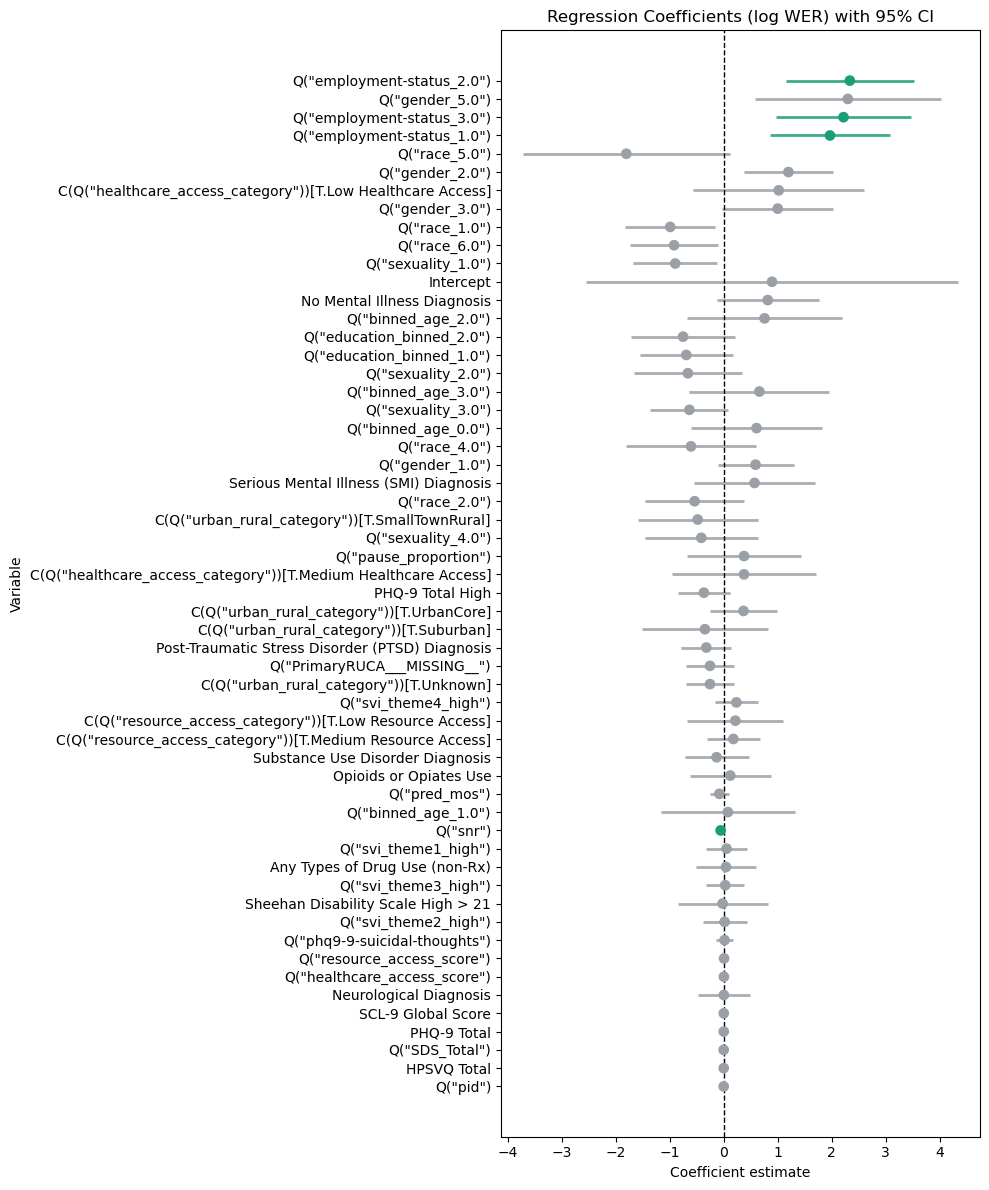

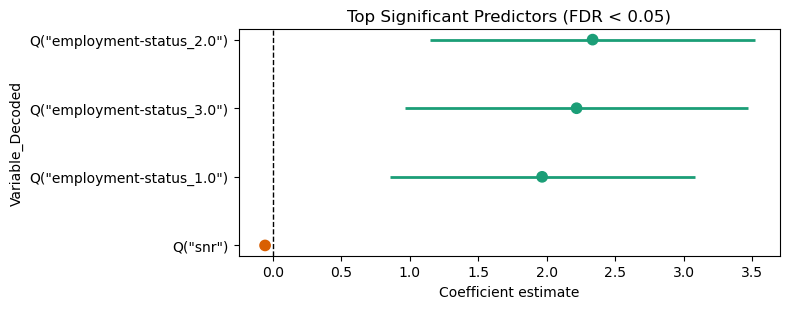

In [499]:
# Add Graph of Multi-Hypothesis corrected results
# Made this cell using Codex
# Top significant predictors only (FDR-significant), sorted by absolute effect size
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
df = pd.read_csv("/edata/obdw/sandwich_analysis_data/regression_stratified_log_wer.csv")

# Clean/prepare
for col in ["fdr_significant", "bonferroni_significant"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})
df["ci_low"] = df["Coefficient"] - 1.96 * df["Std_Error"]
df["ci_high"] = df["Coefficient"] + 1.96 * df["Std_Error"]

# Optional: drop intercept for readability
plot_df = df[df["Variable"] != "const"].copy()
# Add variable decodes
plot_df['Variable_Decoded'] = plot_df['Variable'].apply(safe_decode)
# Build decoded labels (fallback to original if decode fails/empty)
plot_df["Variable_Decoded"] = (
    plot_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(plot_df["Variable"])
)
plot_df["Variable_Decoded"] = np.where(
    plot_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    plot_df["Variable"],
    plot_df["Variable_Decoded"]
)


# Sort by effect size magnitude
plot_df = plot_df.reindex(plot_df["Coefficient"].abs().sort_values(ascending=True).index)

# Plot: coefficient forest plot with 95% CI
plt.figure(figsize=(10, 12))
colors = np.where(plot_df["fdr_significant"], "#1b9e77", "#9aa0a6")

plt.hlines(
    y=plot_df["Variable_Decoded"],
    xmin=plot_df["ci_low"],
    xmax=plot_df["ci_high"],
    color=colors,
    alpha=0.85,
    linewidth=2
)
plt.scatter(
    plot_df["Coefficient"],
    plot_df["Variable_Decoded"],
    c=colors,
    s=45,
    zorder=3
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Regression Coefficients (log WER) with 95% CI")
plt.xlabel("Coefficient estimate")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


sig_df = df[(df["Variable"] != "const") & (df["fdr_significant"] == True)].copy()
# Build decoded labels (fallback to original if decode fails/empty)
sig_df["Variable_Decoded"] = (
    sig_df["Variable"]
    .apply(lambda v: safe_decode(v) if pd.notna(v) else v)
    .fillna(sig_df["Variable"])
)
sig_df["Variable_Decoded"] = np.where(
    sig_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    sig_df["Variable"],
    sig_df["Variable_Decoded"]
)
if sig_df.empty:
    print("No FDR-significant predictors found.")
else:
    sig_df["ci_low"] = sig_df["Coefficient"] - 1.96 * sig_df["Std_Error"]
    sig_df["ci_high"] = sig_df["Coefficient"] + 1.96 * sig_df["Std_Error"]
    sig_df = sig_df.reindex(sig_df["Coefficient"].abs().sort_values(ascending=True).index)

    plt.figure(figsize=(8, max(3, 0.8 * len(sig_df))))
    colors = np.where(sig_df["Coefficient"] >= 0, "#1b9e77", "#d95f02")

    plt.hlines(
        y=sig_df["Variable_Decoded"],
        xmin=sig_df["ci_low"],
        xmax=sig_df["ci_high"],
        color=colors,
        linewidth=2
    )
    plt.scatter(sig_df["Coefficient"], sig_df["Variable_Decoded"], c=colors, s=55, zorder=3)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Top Significant Predictors (FDR < 0.05)")
    plt.xlabel("Coefficient estimate")
    plt.ylabel("Variable_Decoded")
    plt.tight_layout()
    plt.show()
